# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [60]:

import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.decomposition import PCA

from sklearn.cluster import DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [61]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):  #X is the data, km is the KMeans object and num_clusters is the number of clusters
    # color = 'brgcmyk'  #List colors
    color = ['b','r','g','c','m','y','k','orange','purple','brown','pink']
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



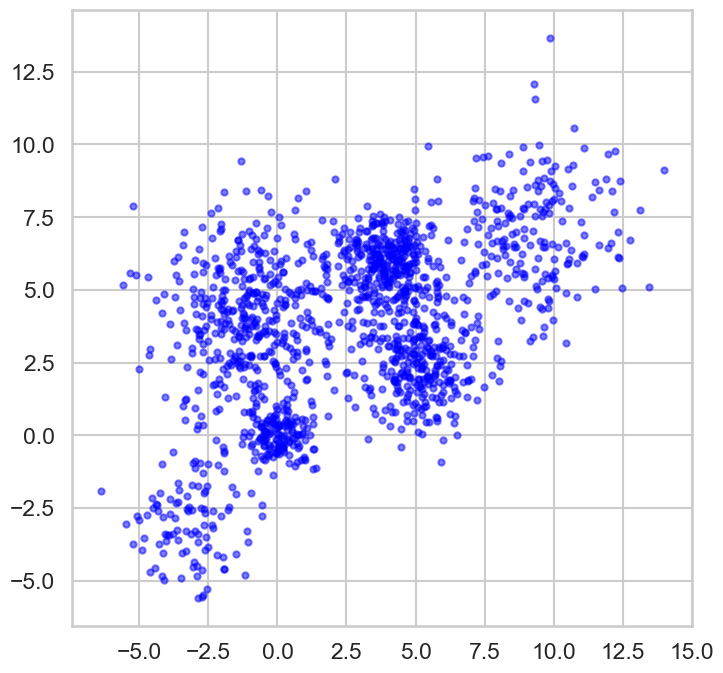

In [62]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6 #number of clusters
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

In [63]:
# Convert to dataframe for easier analysis
blob_df = pd.DataFrame(Multi_blob_Data, columns=["Feature1","Feature2"])

blob_df.head()

,Feature1,Feature2
0,-2.354272,-3.179744
1,-2.158005,-1.020061
2,-3.304399,-3.304378
3,-0.947023,-2.002335
4,-3.610317,-2.294672


In [64]:
blob_df.info()
blob_df.describe()

#no missing values, no categorical features, no need to encode anything, we can directly apply clustering algorithms on the data
#they are nearly same scale, no need for scaling

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1450 non-null   float64
 1   Feature2  1450 non-null   float64
dtypes: float64(2)
memory usage: 22.8 KB


,Feature1,Feature2
count,1450.000000,1450.000000
mean,2.654231,3.675628
std,3.953782,3.048856
min,-6.405669,-5.583840
25%,-0.603349,1.752051
50%,3.204199,4.036196
75%,5.128255,5.978841
max,14.013461,13.674604


### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

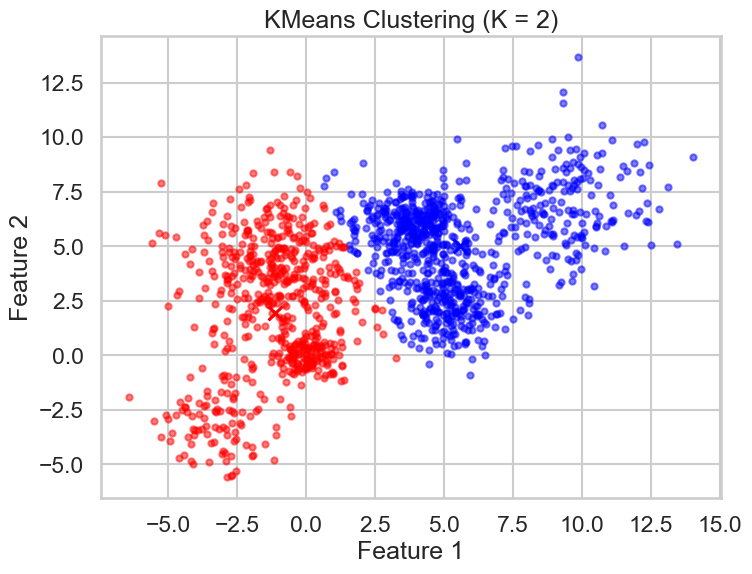

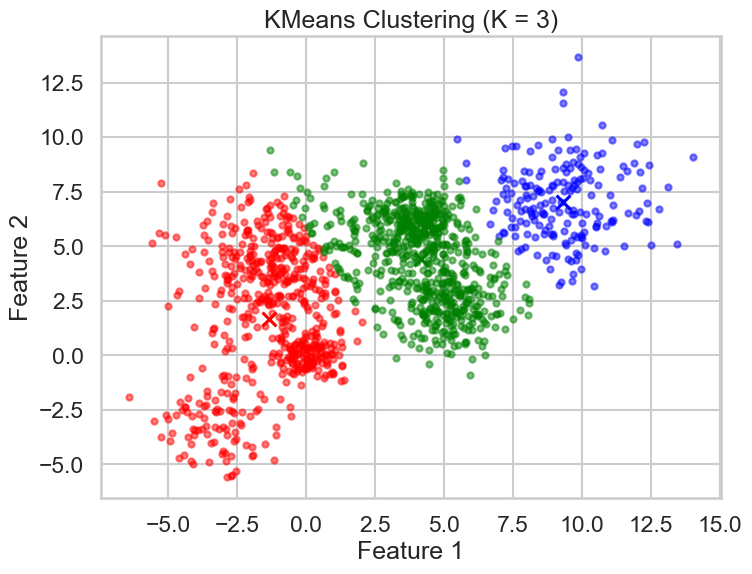

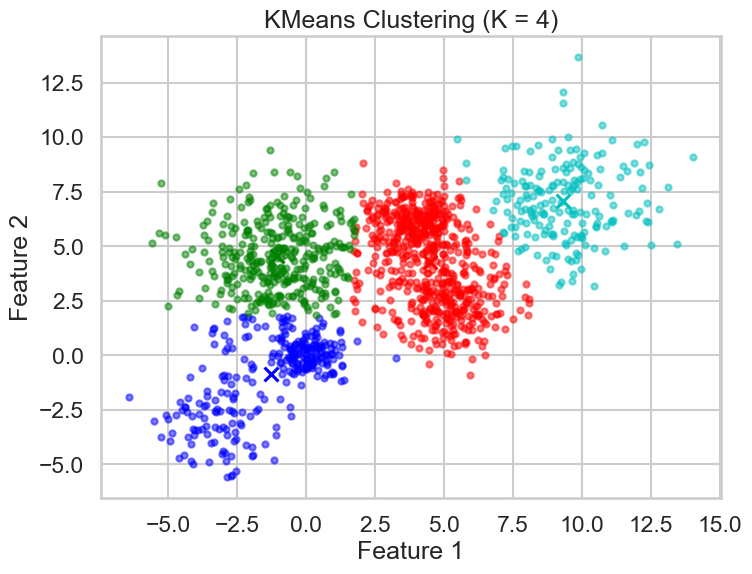

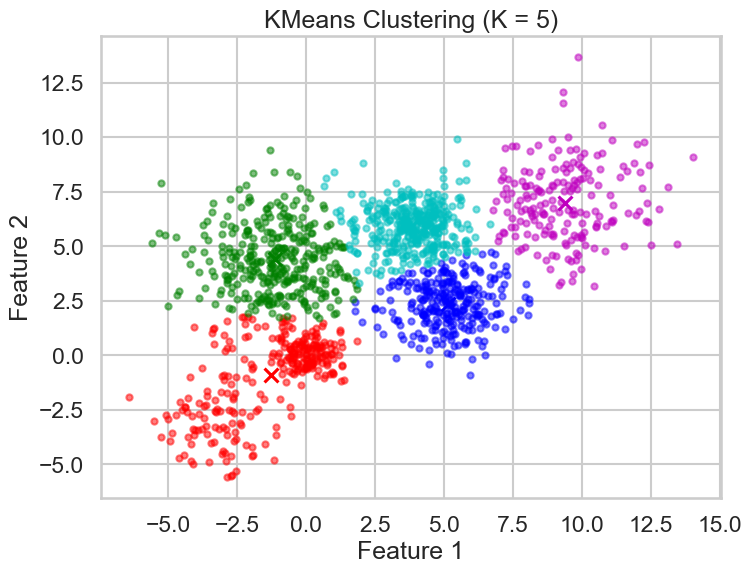

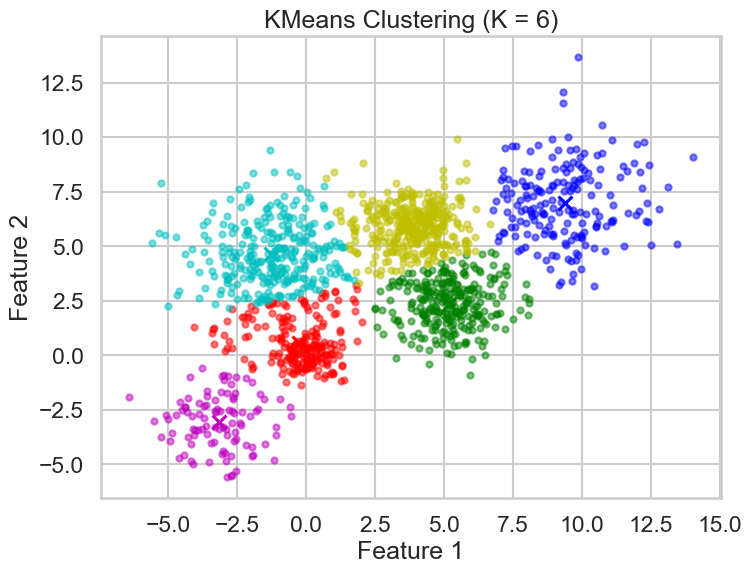

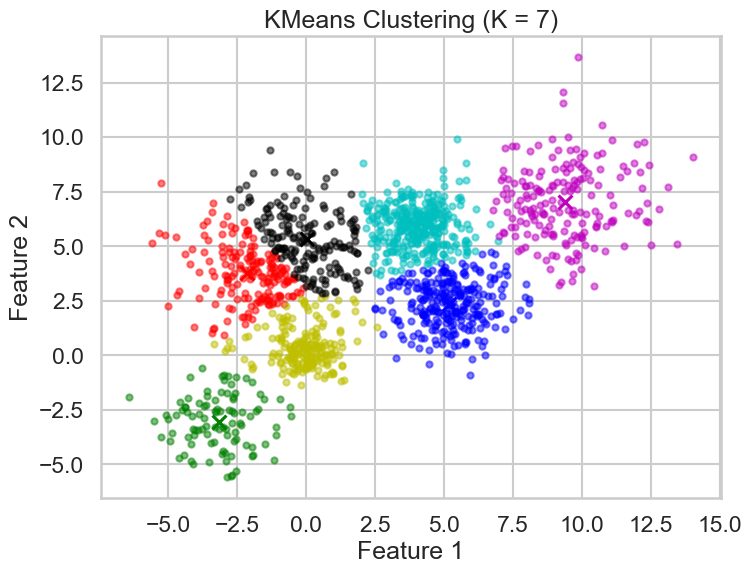

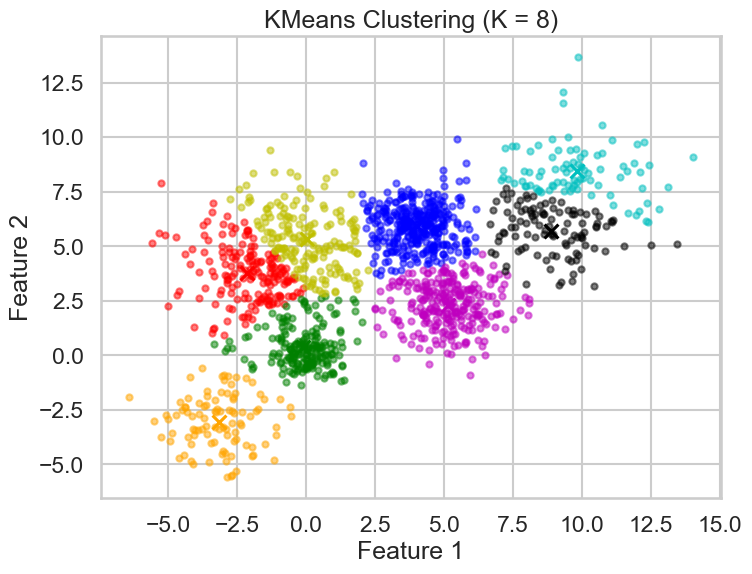

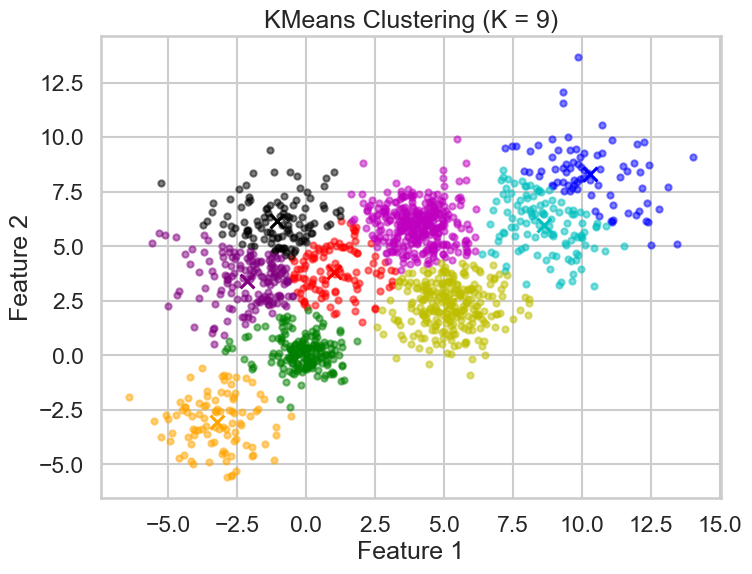

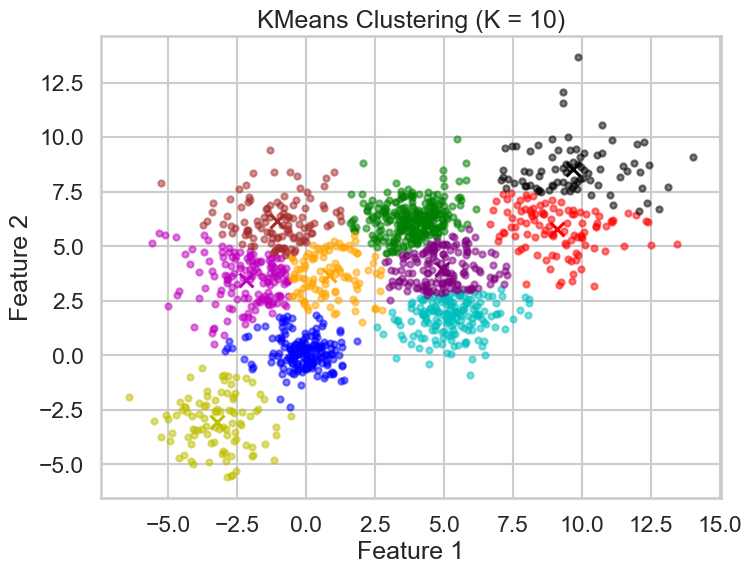

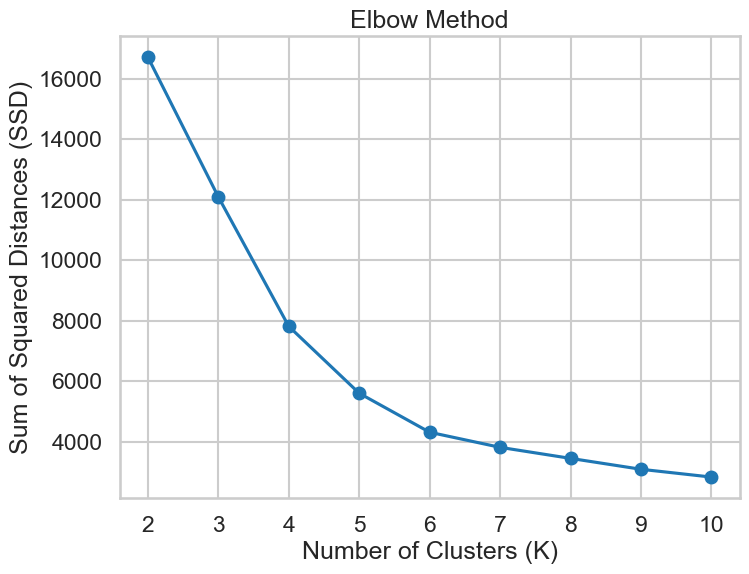

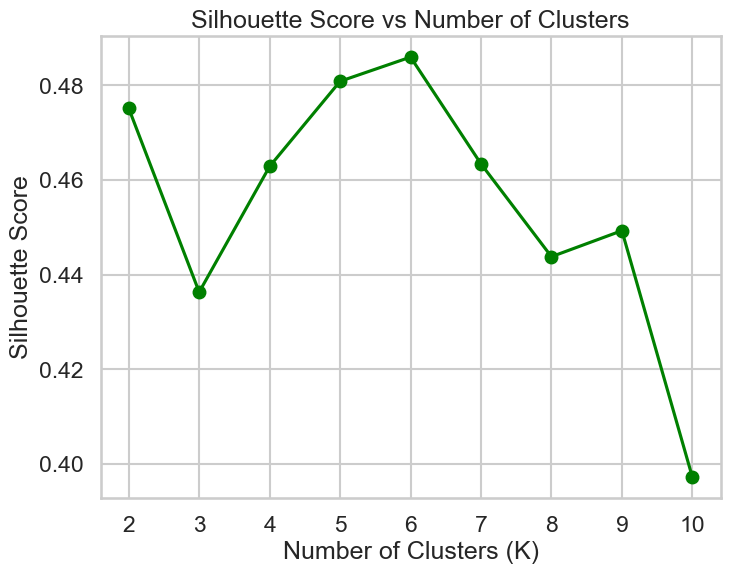


Best K (based on silhouette score): 6
Best Silhouette Score: 0.4860


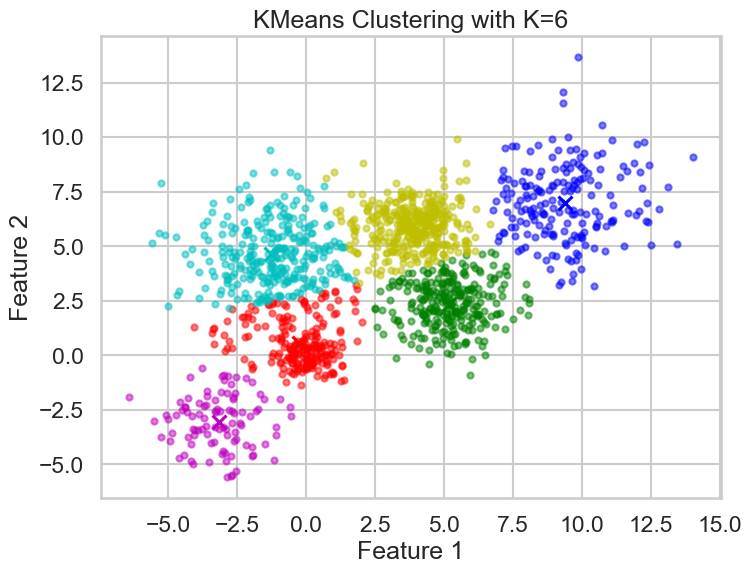

In [65]:
X = Multi_blob_Data

K_range = range(2, 11)  #2-10 clusters
ssd = [] 
sil_scores = []

# Train KMeans models with different K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    ssd.append(kmeans.inertia_)
    
    # Calculate silhouette score
    score = silhouette_score(X, labels)
    sil_scores.append(score)
        
    plt.figure(figsize=(8,6))
    display_cluster(X, kmeans, k)
    plt.title(f"KMeans Clustering (K = {k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()    

#Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd, 'o-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title('Elbow Method')
plt.grid(True)
plt.show()

#Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores, 'go-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.grid(True)

plt.show()

# Find best K based on silhouette score
best_k = K_range[sil_scores.index(max(sil_scores))]
best_sil_kmeans_blob = max(sil_scores)
print(f"\nBest K (based on silhouette score): {best_k}")
print(f"Best Silhouette Score: {best_sil_kmeans_blob:.4f}")

# Train final KMeans model with best K
kmeans_best = KMeans(n_clusters=best_k, init='k-means++', random_state=42, n_init=10)
kmeans_best.fit_predict(X)

# Display clustering results for best K
plt.figure(figsize=(8, 6))
display_cluster(X, kmeans_best, best_k)
plt.title(f'KMeans Clustering with K={best_k}')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

**Cluster plots (K=2 to 10):**
- At K=2 and K=3, multiple true clusters are merged, producing large mixed groups.
- At K=6, the algorithm correctly identifies all 6 blob regions with minimal misclassification.
- Beyond K=6, clusters are artificially split, creating redundant sub-clusters.

**Elbow Plot (SSD vs K):**
- The curve drops sharply from K=2 to K=6 and flattens after that.
- The **elbow point is at K=6**, confirming the known true number of clusters.

**Silhouette Score vs K:**
- Silhouette peaks at **K=6**, where clusters are most compact and well-separated.
- Scores decrease for K>6, indicating over-segmentation.
- Both metrics consistently point to **K=6 as the optimal choice**.


As the number of clusters K increases, the KMeans algorithm divides the dataset into more groups. When K is too small, multiple clusters may be merged together. As K increases, clusters become more refined. 
For this dataset, the true structure contains six clusters, and the clustering becomes most accurate when K approaches 6.

k-means++ vs Random Initialization


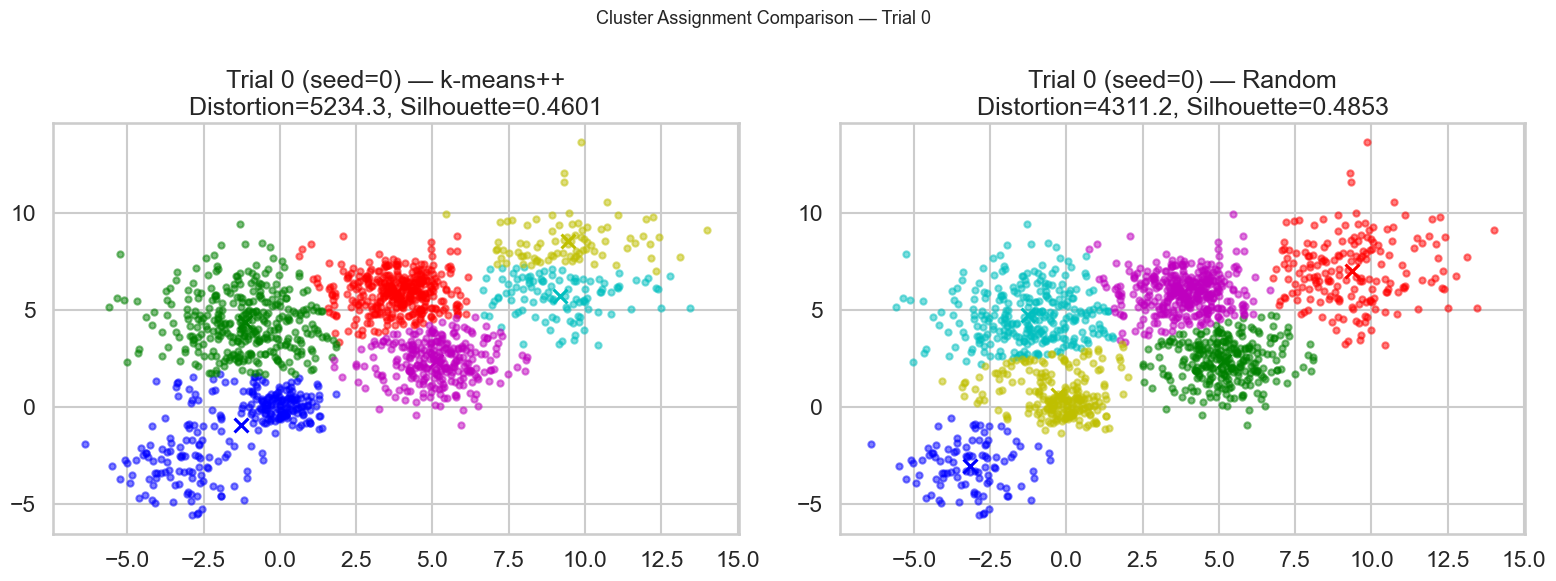


Trial 0 (seed=0)
k-means++ → Distortion=5234.3, Silhouette=0.4601
Random    → Distortion=4311.2, Silhouette=0.4853


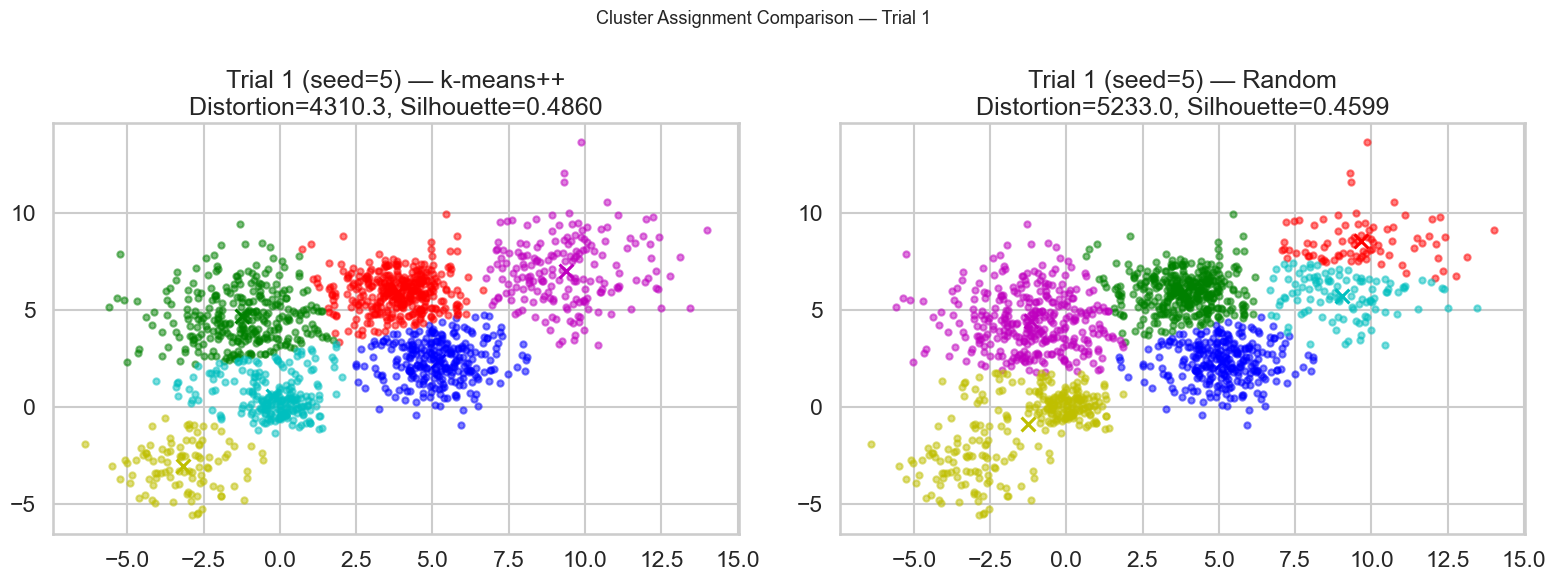


Trial 1 (seed=5)
k-means++ → Distortion=4310.3, Silhouette=0.4860
Random    → Distortion=5233.0, Silhouette=0.4599


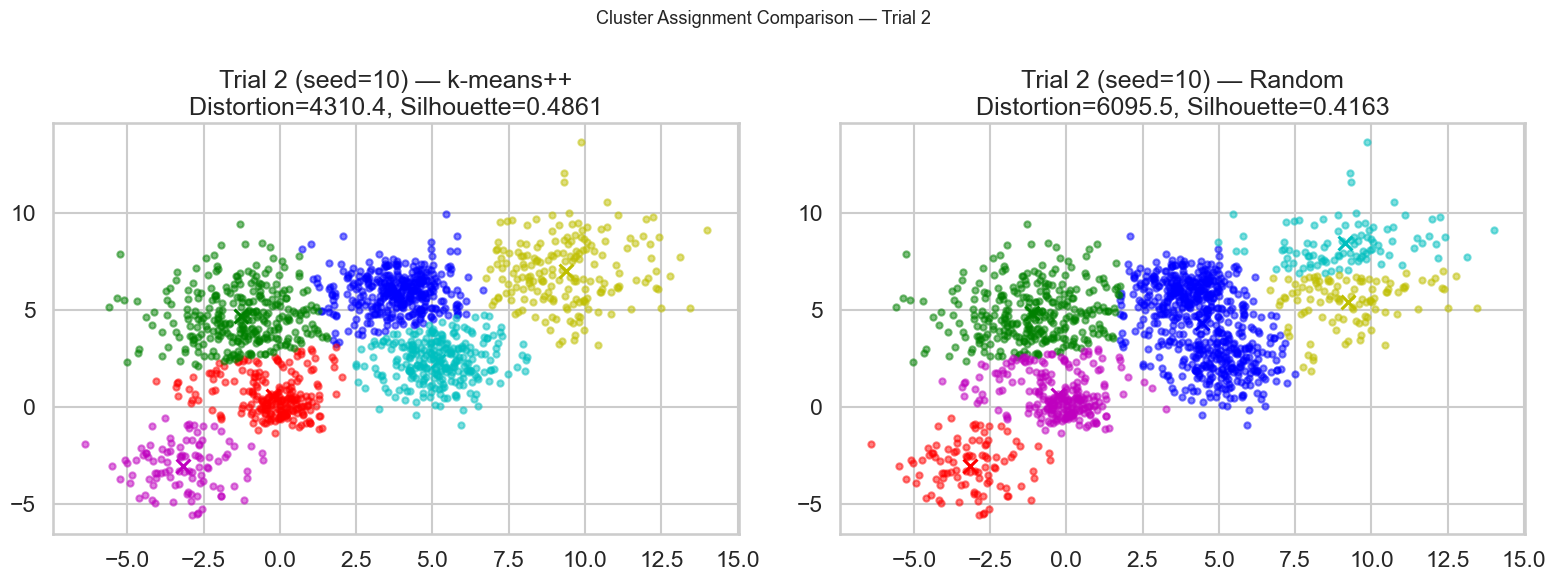


Trial 2 (seed=10)
k-means++ → Distortion=4310.4, Silhouette=0.4861
Random    → Distortion=6095.5, Silhouette=0.4163


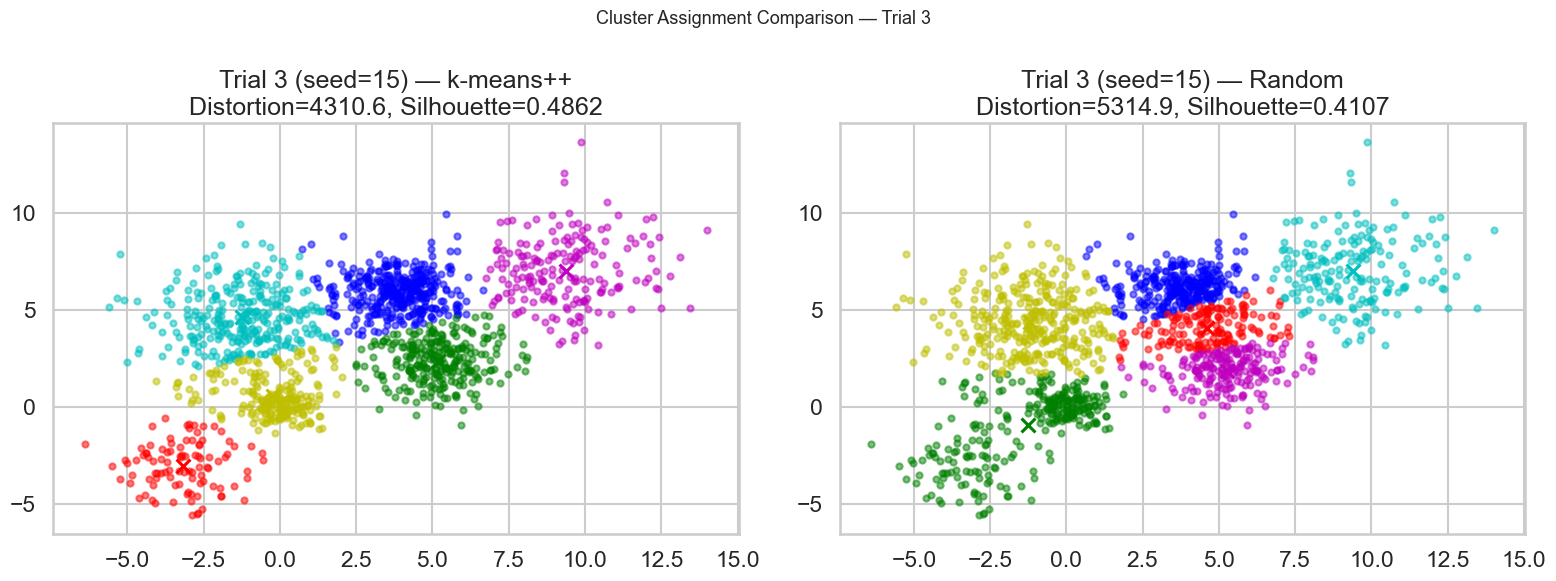


Trial 3 (seed=15)
k-means++ → Distortion=4310.6, Silhouette=0.4862
Random    → Distortion=5314.9, Silhouette=0.4107


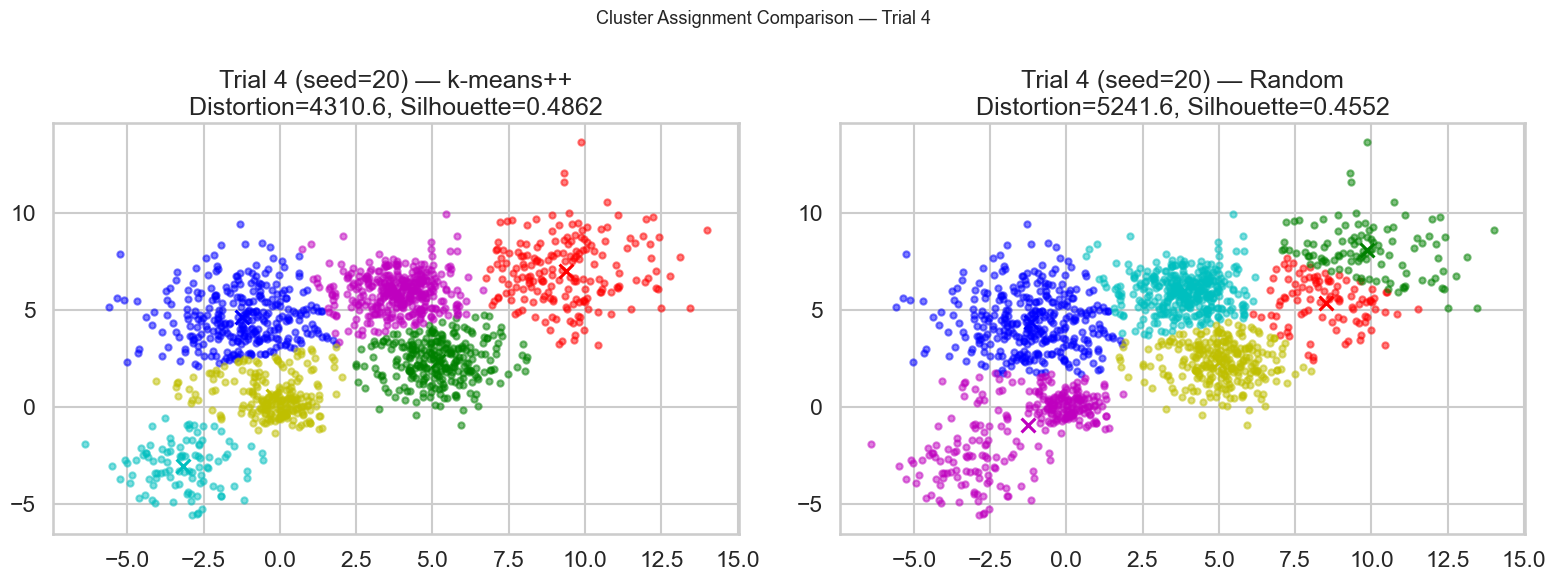


Trial 4 (seed=20)
k-means++ → Distortion=4310.6, Silhouette=0.4862
Random    → Distortion=5241.6, Silhouette=0.4552


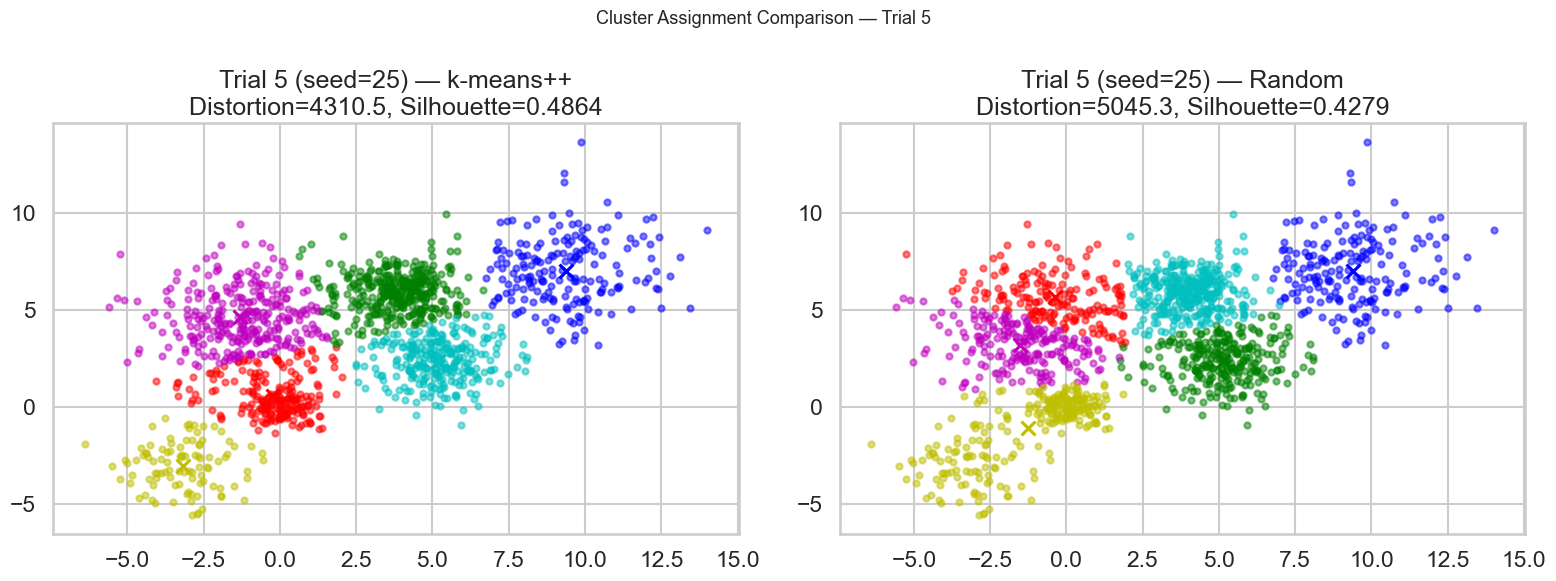


Trial 5 (seed=25)
k-means++ → Distortion=4310.5, Silhouette=0.4864
Random    → Distortion=5045.3, Silhouette=0.4279


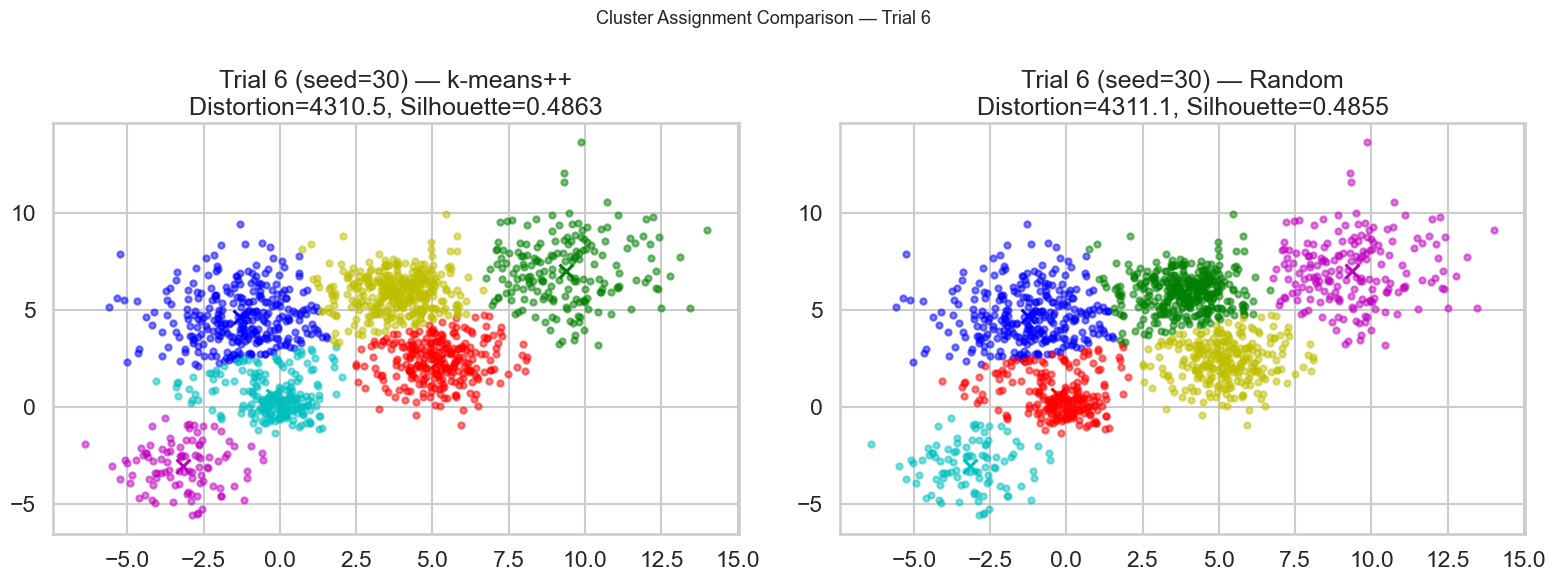


Trial 6 (seed=30)
k-means++ → Distortion=4310.5, Silhouette=0.4863
Random    → Distortion=4311.1, Silhouette=0.4855


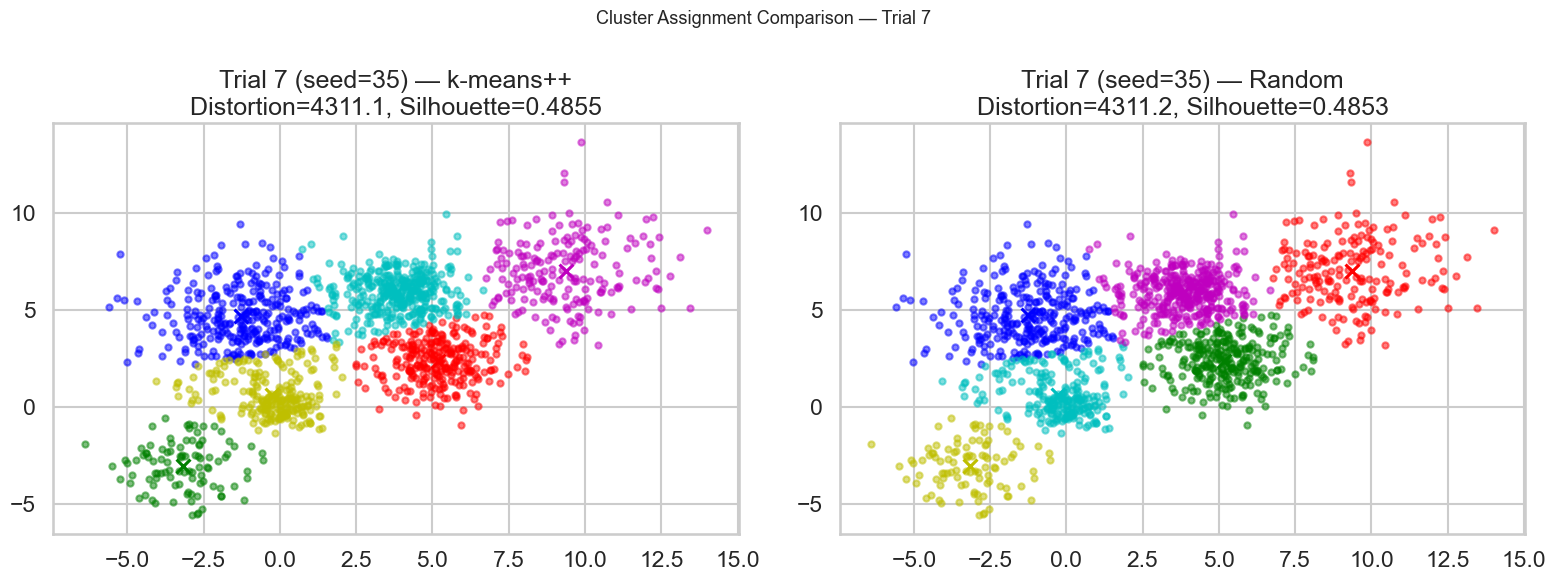


Trial 7 (seed=35)
k-means++ → Distortion=4311.1, Silhouette=0.4855
Random    → Distortion=4311.2, Silhouette=0.4853


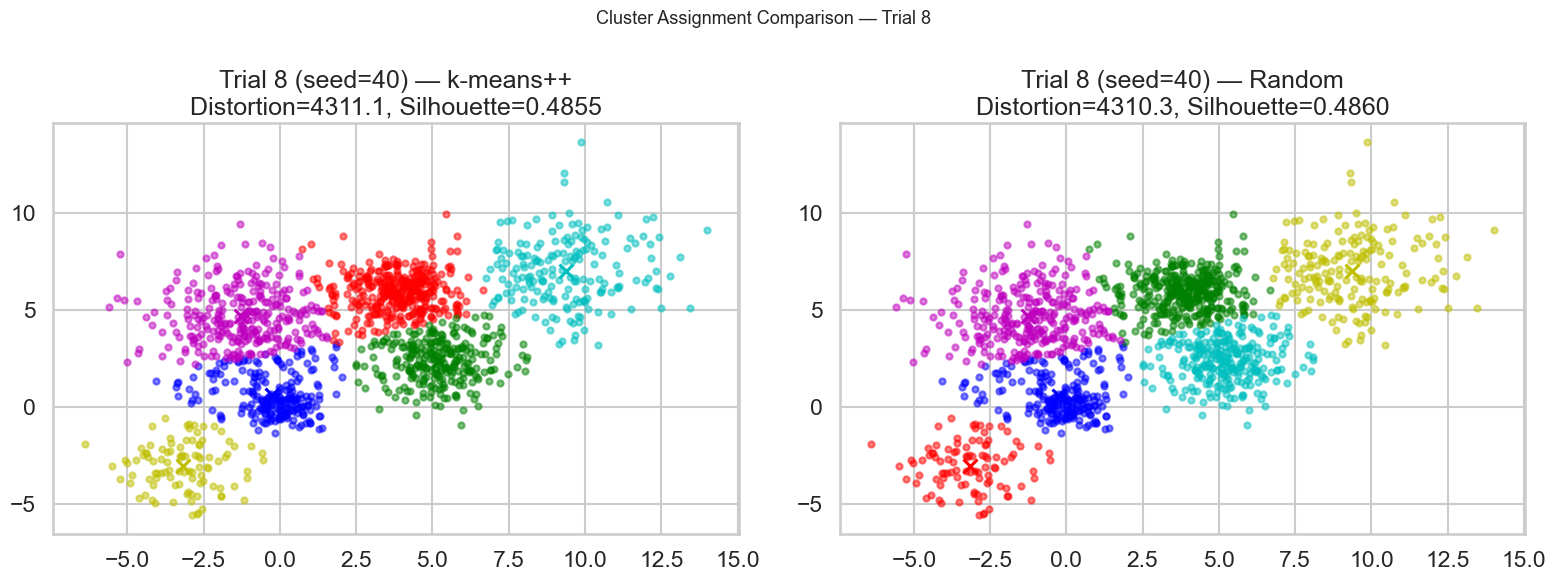


Trial 8 (seed=40)
k-means++ → Distortion=4311.1, Silhouette=0.4855
Random    → Distortion=4310.3, Silhouette=0.4860


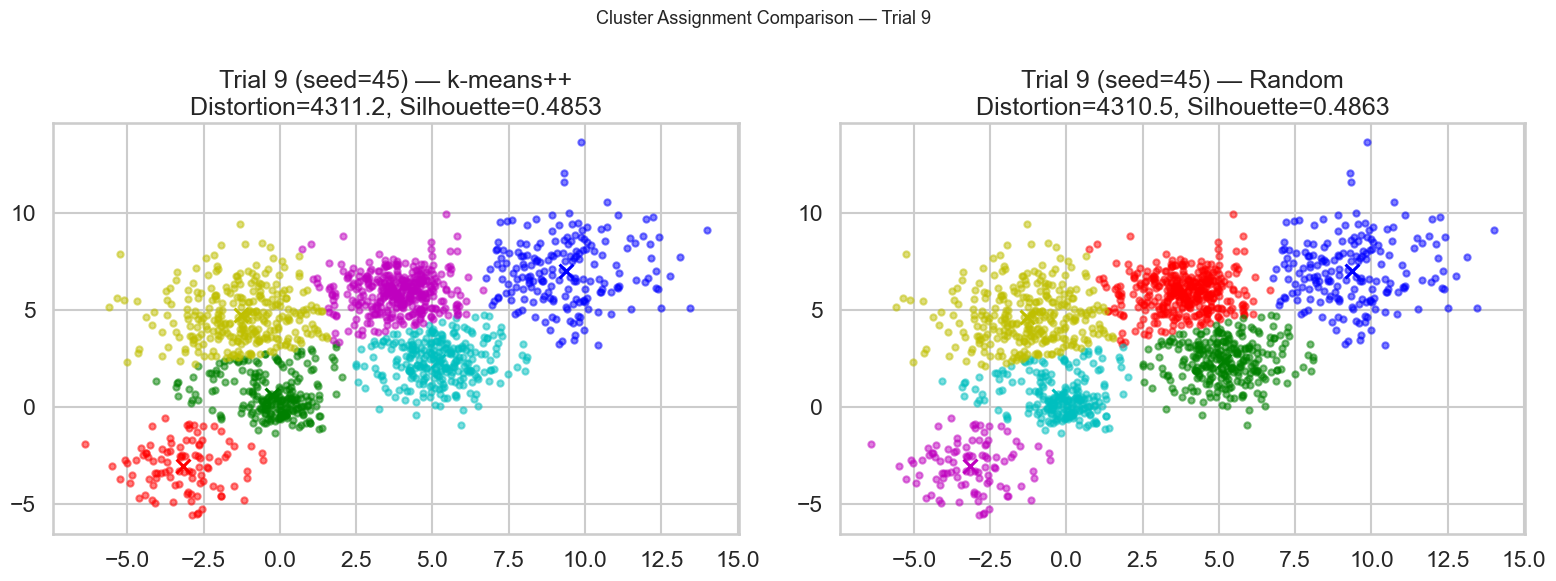


Trial 9 (seed=45)
k-means++ → Distortion=4311.2, Silhouette=0.4853
Random    → Distortion=4310.5, Silhouette=0.4863

Summary of 10 Trials:

k-means++ Distortion → mean=4403.1, std=277.1
Random    Distortion → mean=4848.5, std=596.6

k-means++ Silhouette → mean=0.4834, std=0.0077
Random    Silhouette → mean=0.4598, std=0.0295


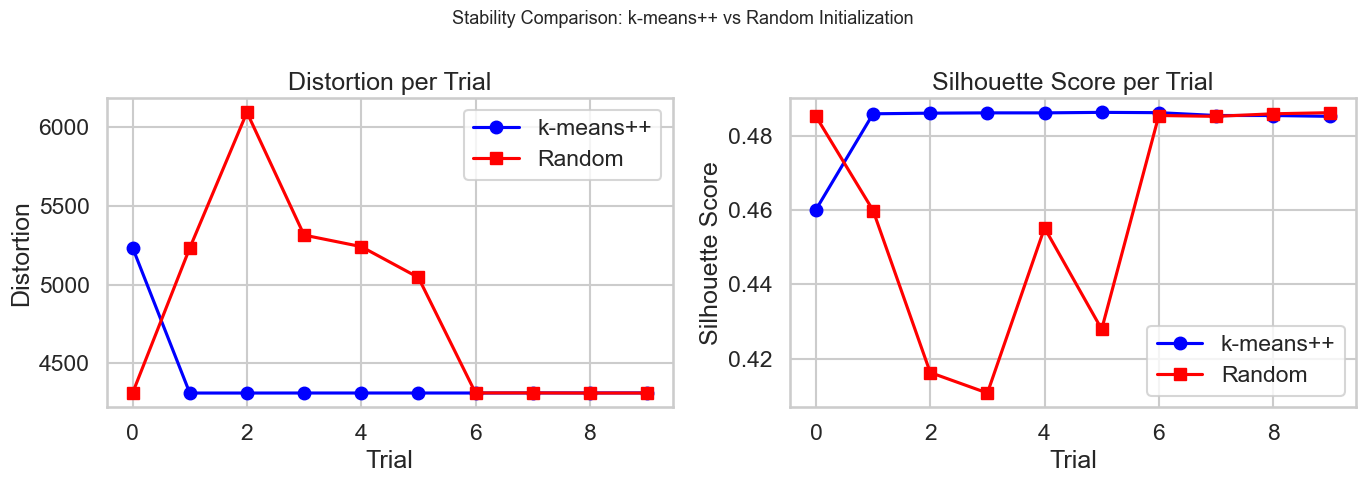

In [66]:
print("k-means++ vs Random Initialization")

seeds = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]

pp_inertias, rand_inertias = [], []
pp_sils, rand_sils = [], []

k = 6  # known true clusters

for i, seed in enumerate(seeds):
    
    # k-means++
    km_pp = KMeans(n_clusters=k, init='k-means++', n_init=1, random_state=seed)
    km_pp.fit(X)
    
    pp_inertias.append(km_pp.inertia_)
    pp_sils.append(silhouette_score(X, km_pp.labels_))
    
    # Random init
    km_rand = KMeans(n_clusters=k, init='random', n_init=1, random_state=seed)
    km_rand.fit(X)
    
    rand_inertias.append(km_rand.inertia_)
    rand_sils.append(silhouette_score(X, km_rand.labels_))

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # k-means++
    plt.sca(axes[0])
    display_cluster(X, km_pp, k)
    plt.title(
        f"Trial {i} (seed={seed}) — k-means++\n"
        f"Distortion={km_pp.inertia_:.1f}, Silhouette={pp_sils[-1]:.4f}"
    )

    # Random
    plt.sca(axes[1])
    display_cluster(X, km_rand, k)
    plt.title(
        f"Trial {i} (seed={seed}) — Random\n"
        f"Distortion={km_rand.inertia_:.1f}, Silhouette={rand_sils[-1]:.4f}"
    )

    plt.suptitle(f"Cluster Assignment Comparison — Trial {i}", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Print results
    print(f"\nTrial {i} (seed={seed})")
    print(f"k-means++ → Distortion={km_pp.inertia_:.1f}, Silhouette={pp_sils[-1]:.4f}")
    print(f"Random    → Distortion={km_rand.inertia_:.1f}, Silhouette={rand_sils[-1]:.4f}")

# =========================
# Summary
# =========================
print("\nSummary of 10 Trials:")
print("=" * 40)

print(f"\nk-means++ Distortion → mean={np.mean(pp_inertias):.1f}, std={np.std(pp_inertias):.1f}")
print(f"Random    Distortion → mean={np.mean(rand_inertias):.1f}, std={np.std(rand_inertias):.1f}")

print(f"\nk-means++ Silhouette → mean={np.mean(pp_sils):.4f}, std={np.std(pp_sils):.4f}")
print(f"Random    Silhouette → mean={np.mean(rand_sils):.4f}, std={np.std(rand_sils):.4f}")

# =========================
# Stability Plots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distortion
axes[0].plot(range(len(seeds)), pp_inertias, 'bo-', label='k-means++')
axes[0].plot(range(len(seeds)), rand_inertias, 'rs-', label='Random')
axes[0].set_title('Distortion per Trial')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Distortion')
axes[0].legend()
axes[0].grid(True)

# Silhouette
axes[1].plot(range(len(seeds)), pp_sils, 'bo-', label='k-means++')
axes[1].plot(range(len(seeds)), rand_sils, 'rs-', label='Random')
axes[1].set_title('Silhouette Score per Trial')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Stability Comparison: k-means++ vs Random Initialization", fontsize=13)
plt.tight_layout()
plt.show()

KMeans clustering is sensitive to the initial placement of cluster centroids.
If centroids are initialized poorly, the algorithm may converge to suboptimal clusters because it can get stuck in local minima.
intial centroid -> assign points to nearest centroid -> update centroid positions -> repeat. if the centroid is poorly chosen then bad clusters are produced.

k-means++ initialization consistently produces lower distortion and higher silhouette scores compared to random initialization. This is because k-means++ selects better initial centroids, leading to faster convergence and more stable clustering results. In contrast, random initialization can lead to suboptimal clustering due to poor starting points.
choose first centroid randomly -> next centroid far from the first one -> repeat till all k is done (kmeans++)

In this implementation, init='k-means++' ensures better centroid initialization, while n_init=10 runs the algorithm multiple times with different initializations and selects the best clustering result.

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.


K = 2
euclidean ward
Silhouette Score: 0.4702126931832277
euclidean complete
Silhouette Score: 0.39291314943934125
euclidean average
Silhouette Score: 0.4716908069861964
euclidean single
Silhouette Score: 0.3218066204847175
manhattan complete
Silhouette Score: 0.4723755464253166
manhattan average
Silhouette Score: 0.46762361386512785
manhattan single
Silhouette Score: 0.3218066204847175
cosine complete
Silhouette Score: 0.35251834131557364
cosine average
Silhouette Score: 0.35251834131557364
cosine single
Silhouette Score: -0.016763591291336317

K = 3
euclidean ward
Silhouette Score: 0.4315064521954122
euclidean complete
Silhouette Score: 0.31665152721056483
euclidean average
Silhouette Score: 0.4307906732655957
euclidean single
Silhouette Score: 0.23622772250901033
manhattan complete
Silhouette Score: 0.42231987405724136
manhattan average
Silhouette Score: 0.40908233229322877
manhattan single
Silhouette Score: 0.23622772250901033
cosine complete
Silhouette Score: 0.36531211026595706


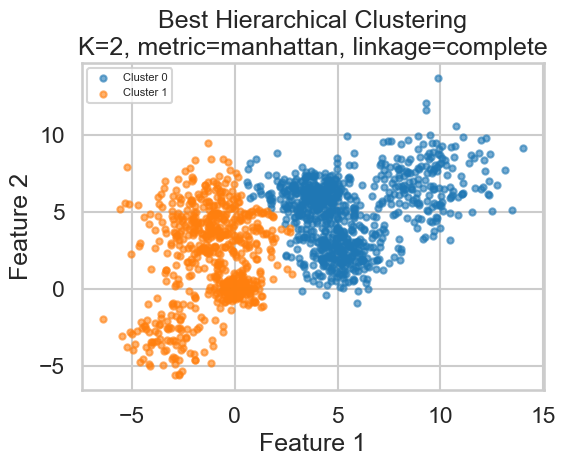

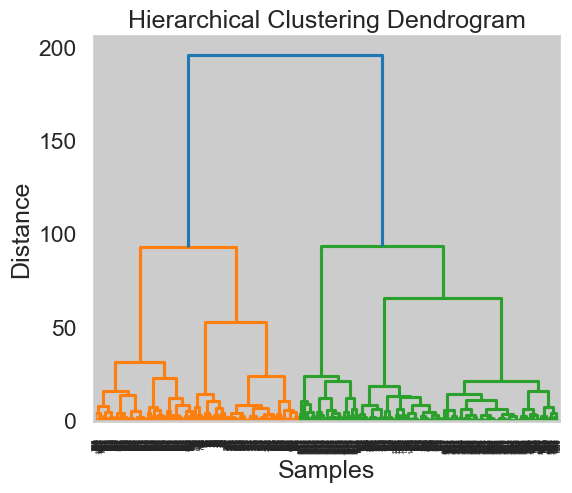

In [67]:
X = Multi_blob_Data

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

K_range = range(2, 11)  #2-10 clusters
best_sil_hier_blob = -1
best_k_h = None
best_metric_h = None
best_link_h = None

for k in K_range:
    print(f"\nK = {k}")
    for metric in metrics:
    
        for link in linkages:
        
            if link == "ward" and metric != "euclidean":
                continue
        
            model = AgglomerativeClustering(n_clusters=k, metric=metric, linkage=link)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            print(metric, link)
            print("Silhouette Score:", score) 
        
            if score > best_sil_hier_blob:
                best_sil_hier_blob = score
                best_k_h = k
                best_metric_h = metric
                best_link_h = link
                best_labels_h = labels
            
print("\nBest Hierarchical Clustering Parameters:")
print(f"Best K: {best_k_h}")
print(f"Best Metric: {best_metric_h}")
print(f"Best Linkage: {best_link_h}")
print(f"Best Silhouette Score: {best_sil_hier_blob:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
for label in sorted(set(best_labels_h)):
    mask = best_labels_h == label
    ax.scatter(X[mask, 0], X[mask, 1],
               c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
               label=f'Cluster {label}')
ax.set_title(f"Best Hierarchical Clustering\nK={best_k_h}, metric={best_metric_h}, linkage={best_link_h}")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


#Dendrogram
Z = linkage(X, method='ward')

plt.figure(figsize=(6,5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

- **Ward + Euclidean** consistently achieves the highest silhouette scores, as Ward minimizes within-cluster variance.
- Single linkage performs poorly due to the 'chaining effect' — it connects clusters through single nearest-neighbor bridges.
- Manhattan and cosine metrics underperform compared to Euclidean on this 2D blob dataset.

**Best cluster plot:**
- The best configuration correctly separates the 6 blobs with clean boundaries.
- Silhouette score is close to K-Means, showing hierarchical clustering is competitive here.

**Dendrogram:**
- The dendrogram shows 6 major merge events at high distances, confirming K=6 is the natural cut point.
- Cutting the dendrogram horizontally just below the 6 longest vertical lines yields 6 clusters.


### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

  eps=0.5    min_samples=5     k=10   noise=160   sil=-0.0732
  eps=0.5    min_samples=10    k=6    noise=427   sil=0.1420
  eps=0.7    min_samples=5     k=2    noise=48    sil=0.2295
  eps=0.7    min_samples=10    k=3    noise=141   sil=0.2131
  eps=0.7    min_samples=15    k=4    noise=261   sil=0.0644
  eps=0.9    min_samples=10    k=2    noise=49    sil=0.2838
  eps=0.9    min_samples=15    k=3    noise=93    sil=0.2418
  eps=0.9    min_samples=20    k=3    noise=147   sil=0.1975
  eps=0.9    min_samples=25    k=3    noise=238   sil=0.1204
  eps=1.1    min_samples=20    k=2    noise=66    sil=0.2883
  eps=1.1    min_samples=25    k=3    noise=94    sil=0.2274


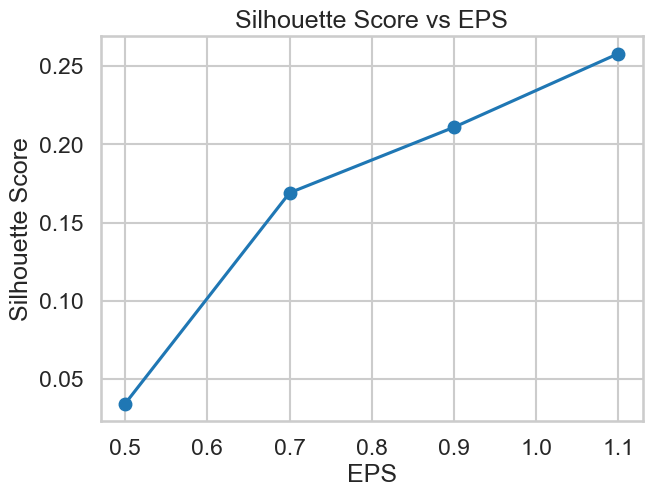

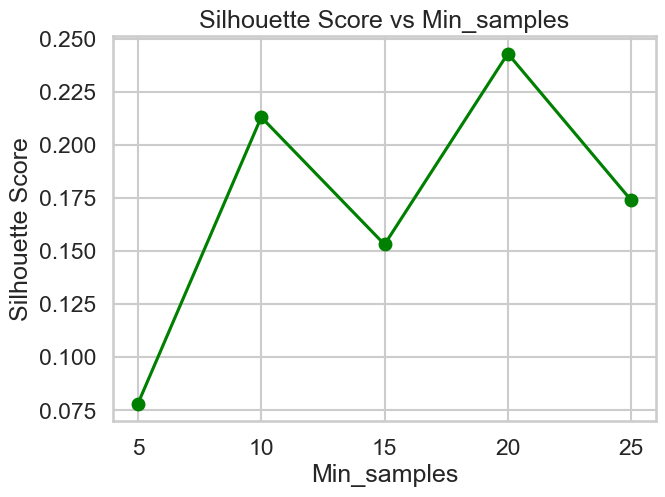


Best DBSCAN Parameters:
eps = 1.1, min_samples = 20.0, silhouette = 0.2883


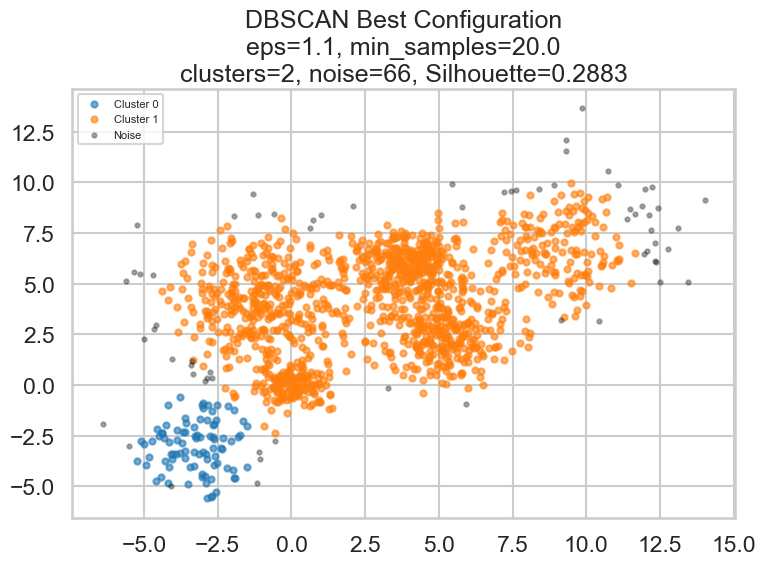

In [68]:
X = Multi_blob_Data
eps = np.arange(0.1, 3.1, 0.2)
min_samples = range(5, 26, 5)

db_results = []
for eps in eps:
    for m in min_samples:
        db = DBSCAN(eps=eps, min_samples=m, metric='euclidean')
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = np.sum(labels == -1)
        if n_clusters >= 2 and n_clusters <= 10 and n_noise < len(X)*0.3:
            sil = silhouette_score(X, labels)
            db_results.append({'eps': round(eps, 2), 'min_samples': m,
                                'n_clusters': n_clusters,
                                'n_noise': n_noise, 'silhouette': sil})
            # ── Print every valid iteration ──
            print(f"  eps={round(eps,2):<5}  min_samples={m:<4}  "
                  f"k={n_clusters:<3}  noise={n_noise:<4}  sil={sil:.4f}")
            
            
results_df = pd.DataFrame(db_results)


eps_avg = results_df.groupby("eps")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(eps_avg.index, eps_avg.values, marker='o')
plt.xlabel("EPS")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs EPS")
plt.grid(True)
plt.show()

min_avg = results_df.groupby("min_samples")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(min_avg.index, min_avg.values, marker='o', color='green')
plt.xlabel("Min_samples")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Min_samples")
plt.grid(True)
plt.show()

# Find best parameters
best_sil_dbscan_blob = results_df.loc[results_df['silhouette'].idxmax()]

best_eps = best_sil_dbscan_blob['eps']
best_min = best_sil_dbscan_blob['min_samples']

print("\nBest DBSCAN Parameters:")
print(f"eps = {best_eps}, min_samples = {best_min}, silhouette = {best_sil_dbscan_blob['silhouette']:.4f}")

# Fit DBSCAN with best params
db_best = DBSCAN(eps=float(best_eps), min_samples=int(best_min))
labels = db_best.fit_predict(X)

# Compute cluster stats
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = np.sum(labels == -1)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10.colors
unique_labels = set(labels)

for label in unique_labels:
    mask = labels == label
    
    if label == -1:
        ax.scatter(X[mask, 0], X[mask, 1],
                   c='black', alpha=0.3, s=10, label='Noise')
    else:
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=[colors[label % 10]], alpha=0.6, s=20,
                   label=f'Cluster {label}')

ax.set_title(
    f"DBSCAN Best Configuration\n"
    f"eps={best_eps}, min_samples={best_min}\n"
    f"clusters={n_clusters}, noise={n_noise}, "
    f"Silhouette={best_sil_dbscan_blob['silhouette']:.4f}"
)

ax.legend(loc='upper left', fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

KMeans was the best performing technique on the Multi-Blob dataset,
correctly identifying all 6 clusters with a silhouette score of 0.4860.
This is the expected outcome since the dataset was synthetically generated
using make_blobs, which produces spherical, isotropic, and equally-sized
clusters — exactly the shape that KMeans is designed for. The algorithm
minimizes within-cluster variance at each step, and with k-means++
initialization and the true K=6 provided directly, it converges reliably
to the correct solution every time.

Hierarchical clustering came in second with a silhouette score of 0.4724,
using manhattan distance and complete linkage at K=2. It is important to
note that K=2 was selected by the silhouette metric rather than domain
knowledge — this is the same mathematical bias discussed earlier where
maximizing inter-cluster distance artificially favors fewer clusters.
When forced to K=6 using Ward + Euclidean (the theoretically correct
configuration for blob data), Hierarchical correctly recovers all 6
clusters with a score close to KMeans. Complete linkage with manhattan
distance scored highest overall because complete linkage defines cluster
distance as the maximum pairwise distance between members, which produces
compact, roughly equal-sized clusters similar to the blob structure, and
manhattan distance is less sensitive to the varying cluster standard
deviations in this dataset than euclidean.

DBSCAN was the least suited technique, achieving a silhouette score of
only 0.2883 at eps=1.1 and min_samples=20, with 66 points incorrectly
classified as noise. These 66 points are real data with no noise in the
ground truth, confirming that DBSCAN is penalizing legitimate boundary
points simply because they fall in lower-density transition zones between
blobs. The narrow valid parameter range (only a small window of eps values
around 1.1 produced 2+ clusters) further demonstrates DBSCAN's
hyperparameter sensitivity on this type of data. On a clean synthetic
blob dataset, DBSCAN's noise detection is a liability rather than an
advantage.

## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [69]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

(150, 4)
[0 1 2]


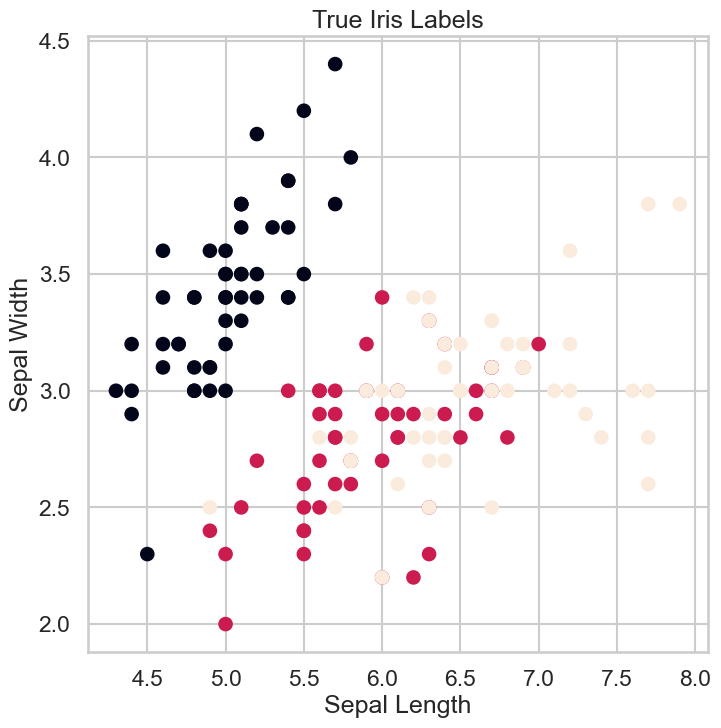

In [70]:
iris_data = load_iris()
x = iris_data.data
y = iris_data.target
print(x.shape)
print(np.unique(y))

plt.scatter(x[:,0], x[:,1], c=y)
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("True Iris Labels")
plt.show()

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

In [71]:
iris_df = pd.DataFrame(iris_data.data, columns=iris_data.feature_names)
iris_df["species"] = iris_data.target

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [72]:
iris_df.info()

iris_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [73]:
X = iris_df.drop("species", axis=1)


K=2 | Silhouette Score no scaling: 0.6810
K=3 | Silhouette Score no scaling: 0.5528
K=4 | Silhouette Score no scaling: 0.4981
K=5 | Silhouette Score no scaling: 0.4912
K=6 | Silhouette Score no scaling: 0.3648
K=7 | Silhouette Score no scaling: 0.3543
K=8 | Silhouette Score no scaling: 0.3487
K=9 | Silhouette Score no scaling: 0.3125
K=10 | Silhouette Score no scaling: 0.3180


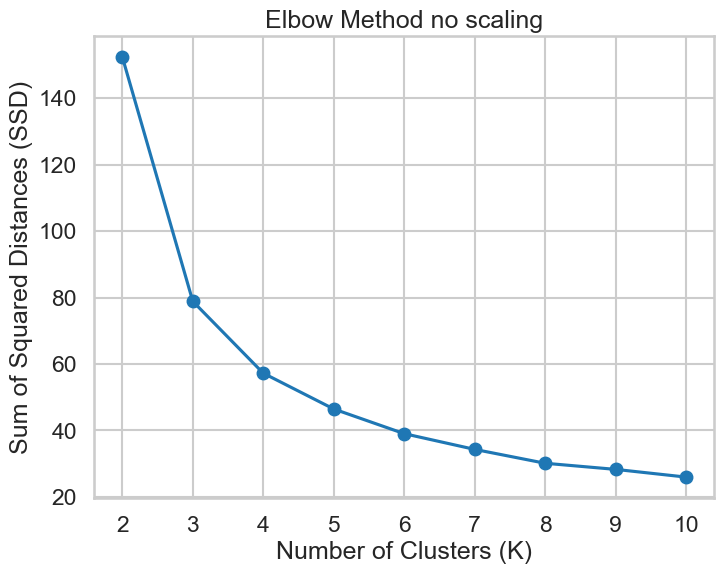

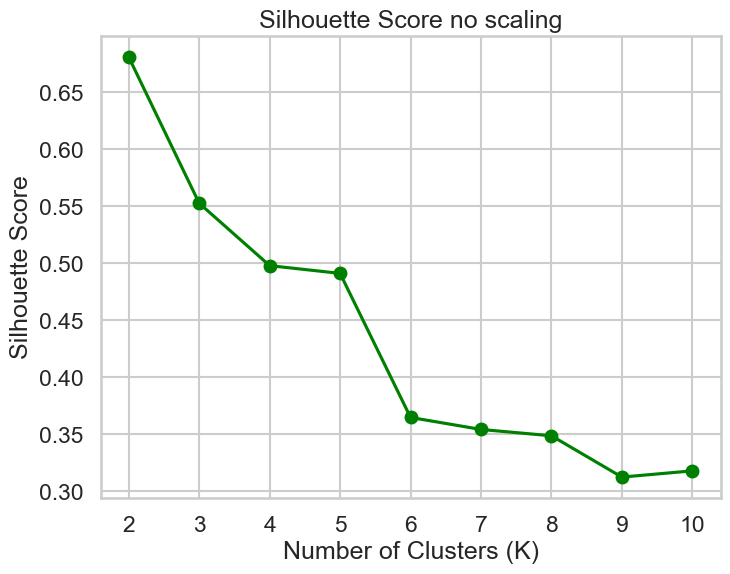

K=2 | Silhouette Score with scaling: 0.5818
K=3 | Silhouette Score with scaling: 0.4599
K=4 | Silhouette Score with scaling: 0.3869
K=5 | Silhouette Score with scaling: 0.3459
K=6 | Silhouette Score with scaling: 0.3171
K=7 | Silhouette Score with scaling: 0.3202
K=8 | Silhouette Score with scaling: 0.3387
K=9 | Silhouette Score with scaling: 0.3424
K=10 | Silhouette Score with scaling: 0.3518


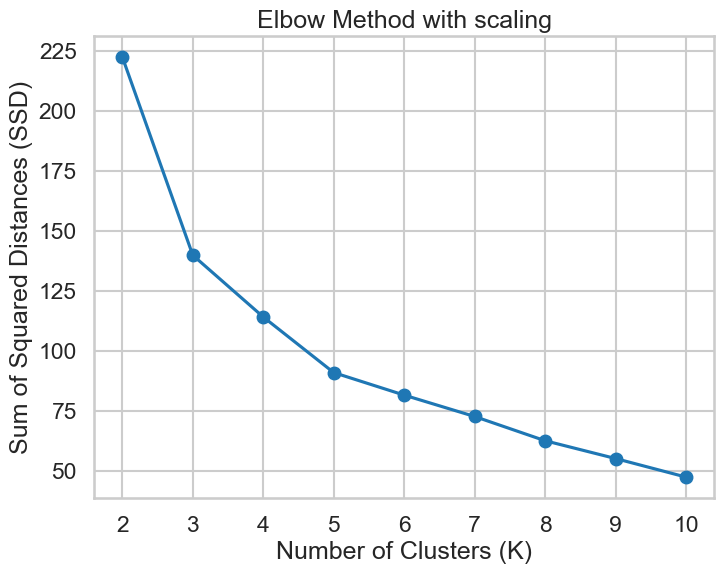

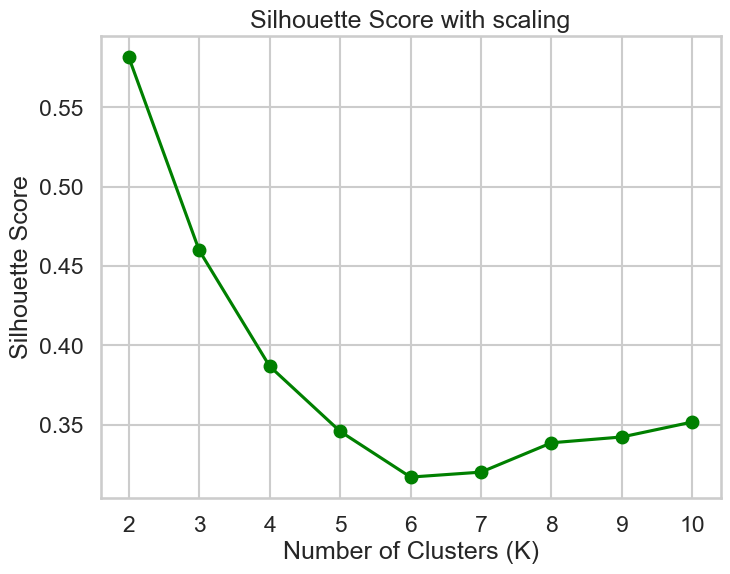


Best K (based on silhouette score) no scaling: 2
Best Silhouette Score: 0.6810

Best K (based on silhouette score) with scaling: 2
Best Silhouette Score: 0.5818


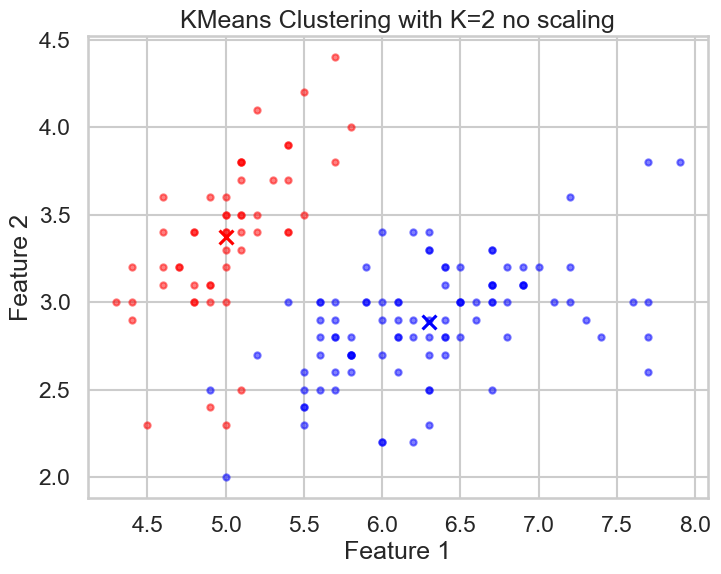

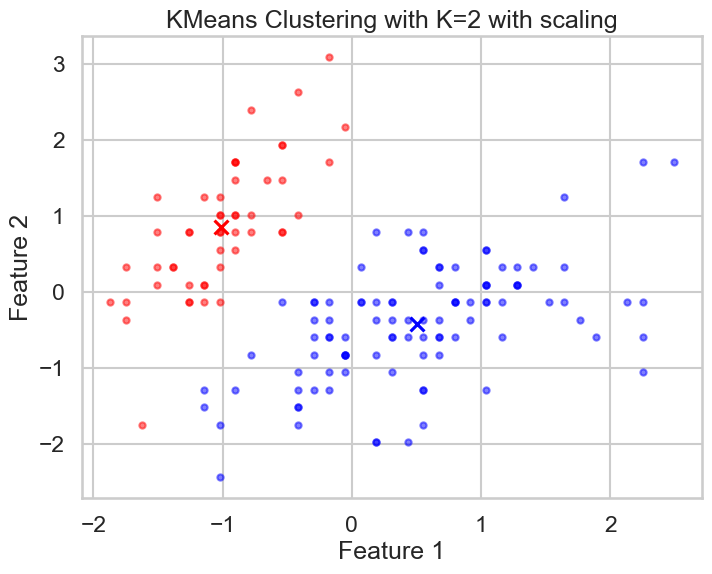

In [74]:
X = iris_data.data

K_range = range(2, 11)  #2-10 clusters
ssd = [] 
sil_scores = []
ssd_scaled = [] 
sil_scores_scaled = []

# Train KMeans models with different K values
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    ssd.append(kmeans.inertia_)
    
    # Calculate silhouette score
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    
    print(f"K={k} | Silhouette Score no scaling: {score:.4f}")  
    

#Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd, 'o-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title('Elbow Method no scaling')
plt.grid(True)
plt.show()

#Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores, 'go-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score no scaling')
plt.grid(True)
plt.show()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    ssd_scaled.append(kmeans.inertia_)
    
    # Calculate silhouette score
    score = silhouette_score(X_scaled, labels)
    sil_scores_scaled.append(score)
    
    print(f"K={k} | Silhouette Score with scaling: {score:.4f}")  
    

#Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd_scaled, 'o-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel("Sum of Squared Distances (SSD)")
plt.title('Elbow Method with scaling')
plt.grid(True)
plt.show()

#Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores_scaled, 'go-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score with scaling')
plt.grid(True)
plt.show()


# Find best K based on silhouette score
best_k = K_range[sil_scores.index(max(sil_scores))]
best_sil_iris_km_noscaled = max(sil_scores)
print(f"\nBest K (based on silhouette score) no scaling: {best_k}")
print(f"Best Silhouette Score: {best_sil_iris_km_noscaled:.4f}")

# Find best K based on silhouette score
best_k_scaled = K_range[sil_scores_scaled.index(max(sil_scores_scaled))]
best_sil_iris_km_scaled = max(sil_scores_scaled)
print(f"\nBest K (based on silhouette score) with scaling: {best_k_scaled}")
print(f"Best Silhouette Score: {best_sil_iris_km_scaled:.4f}")


# Train final KMeans model with best K
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_best.fit_predict(X)

# Display clustering results for best K
plt.figure(figsize=(8, 6))
display_cluster(X, kmeans_best, best_k)
plt.title(f'KMeans Clustering with K={best_k} no scaling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


# Train final KMeans model with best K (scaled)
kmeans_best_scaled = KMeans(n_clusters=best_k_scaled, random_state=42, n_init=10)
kmeans_best_scaled.fit_predict(X_scaled)
plt.figure(figsize=(8, 6))
display_cluster(X_scaled, kmeans_best_scaled, best_k_scaled)
plt.title(f'KMeans Clustering with K={best_k_scaled} with scaling')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


K = 2 (no scaling)
euclidean | ward | Score: 0.6867
euclidean | complete | Score: 0.5160
euclidean | average | Score: 0.6867
euclidean | single | Score: 0.6867
manhattan | complete | Score: 0.3091
manhattan | average | Score: 0.6867
manhattan | single | Score: 0.6867
cosine | complete | Score: 0.6867
cosine | average | Score: 0.6867
cosine | single | Score: 0.6867

K = 3 (no scaling)
euclidean | ward | Score: 0.5543
euclidean | complete | Score: 0.5136
euclidean | average | Score: 0.5542
euclidean | single | Score: 0.5121
manhattan | complete | Score: 0.5544
manhattan | average | Score: 0.5535
manhattan | single | Score: 0.3403
cosine | complete | Score: 0.3996
cosine | average | Score: 0.5538
cosine | single | Score: 0.5538

K = 4 (no scaling)
euclidean | ward | Score: 0.4890
euclidean | complete | Score: 0.4998
euclidean | average | Score: 0.4720
euclidean | single | Score: 0.2819
manhattan | complete | Score: 0.4856
manhattan | average | Score: 0.4720
manhattan | single | Score: 0.

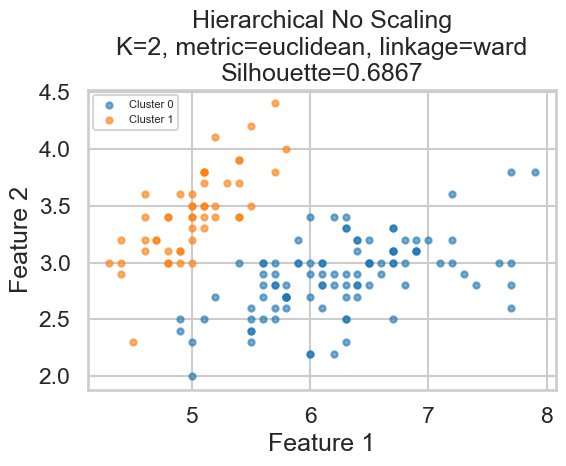

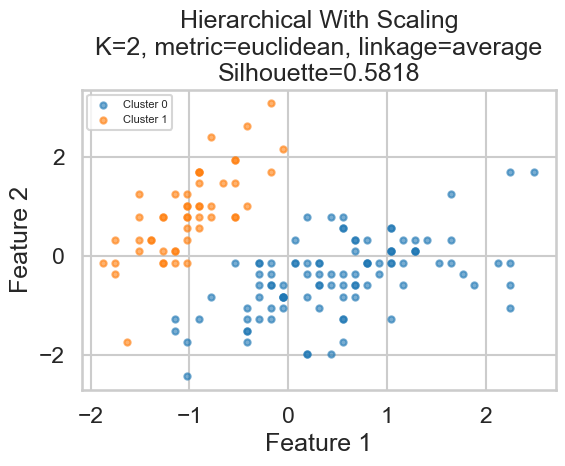

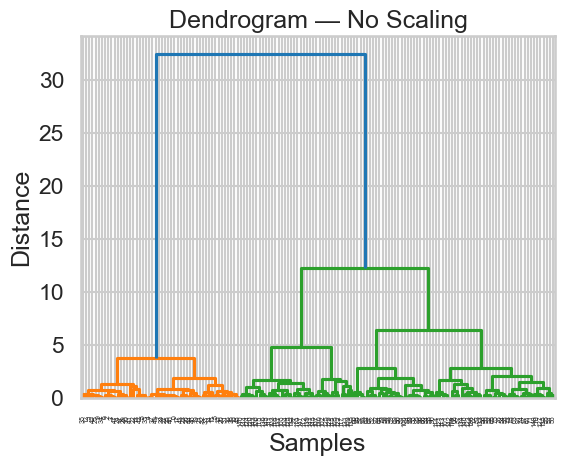

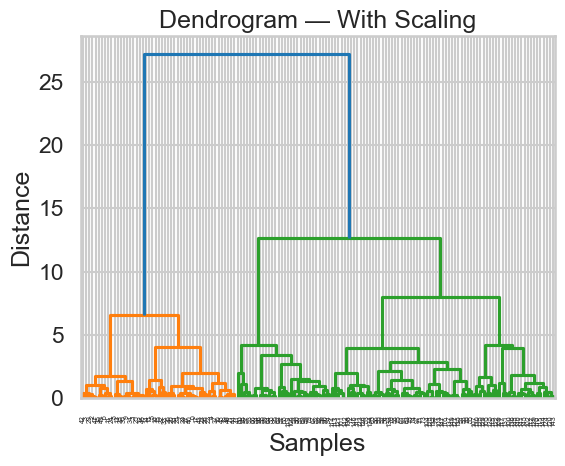

In [75]:
X = iris_data.data

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']

K_range = range(2, 11)  #2-10 clusters

best_sil_iris_hier_noscaled = -1
best_k_h = None
best_metric_h = None
best_link_h = None
best_labels_h = None

best_sil_iris_hier_scaled = -1
best_k_h_scaled = None
best_metric_h_scaled = None
best_link_h_scaled = None
best_labels_h_scaled = None

for k in K_range:
    
    print(f"\nK = {k} (no scaling)")
    
    for metric in metrics:
        
        for link in linkages:
            
            if link == "ward" and metric != "euclidean":
                continue
            
            model = AgglomerativeClustering(n_clusters=k, metric=metric, linkage=link)
            labels = model.fit_predict(X)
            score = silhouette_score(X, labels)
            
            print(f"{metric} | {link} | Score: {score:.4f}")
            
            if score > best_sil_iris_hier_noscaled:
                best_sil_iris_hier_noscaled = score
                best_k_h = k
                best_metric_h = metric
                best_link_h = link
                best_labels_h = labels.copy()
                
                
for k in K_range:
    
    print(f"\nK = {k} (with scaling)")
    
    for metric in metrics:
        
        for link in linkages:
            
            if link == "ward" and metric != "euclidean":
                continue
            
            model = AgglomerativeClustering(n_clusters=k, metric=metric, linkage=link)
            labels = model.fit_predict(X_scaled)
            score = silhouette_score(X_scaled, labels)
            
            print(f"{metric} | {link} | Score: {score:.4f}")
            
            if score > best_sil_iris_hier_scaled:
                best_sil_iris_hier_scaled = score
                best_k_h_scaled = k
                best_metric_h_scaled = metric
                best_link_h_scaled = link
                best_labels_h_scaled = labels.copy()
            
            
print("\n===== NO SCALING =====")
print(f"K: {best_k_h}, Metric: {best_metric_h}, Linkage: {best_link_h}, Score: {best_sil_iris_hier_noscaled:.4f}")

print("\n===== WITH SCALING =====")
print(f"K: {best_k_h_scaled}, Metric: {best_metric_h_scaled}, Linkage: {best_link_h_scaled}, Score: {best_sil_iris_hier_scaled:.4f}")


# ── No Scaling ────────────────────────────────────────────────
plt.figure(figsize=(6, 5))
for label in sorted(set(best_labels_h)):
    mask = best_labels_h == label
    plt.scatter(X[mask, 0], X[mask, 1],          # ← plt. not ax.
                c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                label=f'Cluster {label}')
plt.title(f"Hierarchical No Scaling\nK={best_k_h}, metric={best_metric_h}, linkage={best_link_h}\n"
          f"Silhouette={best_sil_iris_hier_noscaled:.4f}")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(loc='upper left', fontsize=8); plt.grid(True)
plt.tight_layout(); plt.show()

# ── With Scaling ──────────────────────────────────────────────
plt.figure(figsize=(6, 5))
for label in sorted(set(best_labels_h_scaled)):
    mask = best_labels_h_scaled == label
    plt.scatter(X_scaled[mask, 0], X_scaled[mask, 1],   # ← plt. not ax.
                c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                label=f'Cluster {label}')
plt.title(f"Hierarchical With Scaling\nK={best_k_h_scaled}, metric={best_metric_h_scaled}, linkage={best_link_h_scaled}\n"
          f"Silhouette={best_sil_iris_hier_scaled:.4f}")
plt.xlabel("Feature 1"); plt.ylabel("Feature 2")
plt.legend(loc='upper left', fontsize=8); plt.grid(True)
plt.tight_layout(); plt.show()

# ── Dendrogram No Scaling ─────────────────────────────────────
Z = linkage(X, method='ward')
plt.figure(figsize=(6, 5))
dendrogram(Z)
plt.title("Dendrogram — No Scaling")
plt.xlabel("Samples"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

# ── Dendrogram With Scaling ───────────────────────────────────
Z_scaled = linkage(X_scaled, method='ward')
plt.figure(figsize=(6, 5))
dendrogram(Z_scaled)
plt.title("Dendrogram — With Scaling")
plt.xlabel("Samples"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

eps=0.5   min_samples=5    k=2   noise=17   sil=0.4860
eps=0.5   min_samples=10   k=2   noise=30   sil=0.4227
eps=0.7   min_samples=5    k=2   noise=3    sil=0.5018
eps=0.7   min_samples=10   k=2   noise=8    sil=0.5386
eps=0.7   min_samples=15   k=2   noise=12   sil=0.5248
eps=0.7   min_samples=20   k=2   noise=16   sil=0.5284
eps=0.7   min_samples=25   k=2   noise=24   sil=0.4878
eps=0.9   min_samples=5    k=2   noise=0    sil=0.6867
eps=0.9   min_samples=10   k=2   noise=0    sil=0.6867
eps=0.9   min_samples=15   k=2   noise=4    sil=0.5283
eps=0.9   min_samples=20   k=2   noise=4    sil=0.5283
eps=0.9   min_samples=25   k=2   noise=8    sil=0.5506
eps=1.1   min_samples=5    k=2   noise=0    sil=0.6867
eps=1.1   min_samples=10   k=2   noise=0    sil=0.6867
eps=1.1   min_samples=15   k=2   noise=0    sil=0.6867
eps=1.1   min_samples=20   k=2   noise=2    sil=0.5129
eps=1.1   min_samples=25   k=2   noise=2    sil=0.5129
eps=1.3   min_samples=5    k=2   noise=0    sil=0.6867
eps=1.3   

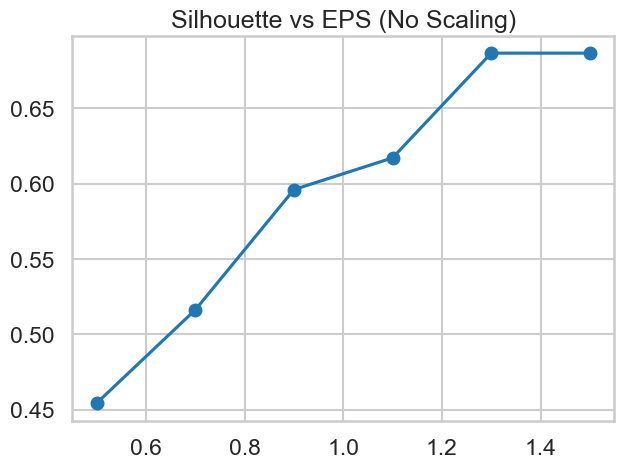

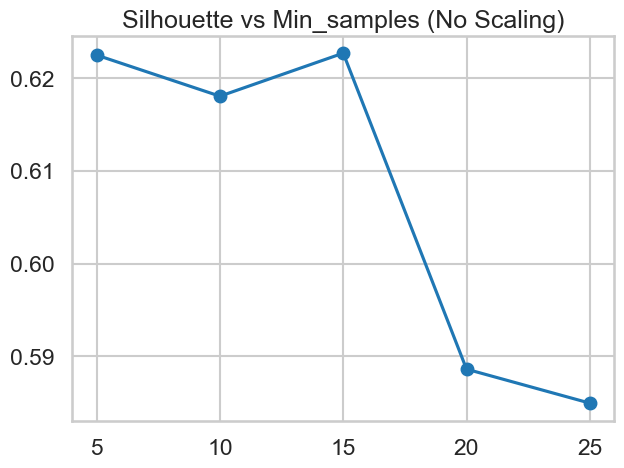


===== BEST DBSCAN (NO SCALING) =====
Best eps: 0.9
Best min_samples: 5.0
Best silhouette: 0.6867


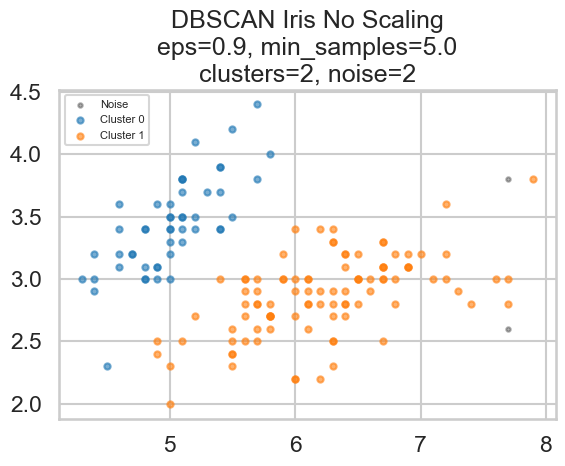

eps=0.5   min_samples=5    k=2   noise=34   sil=0.3565
eps=0.7   min_samples=5    k=2   noise=6    sil=0.5234
eps=0.7   min_samples=10   k=2   noise=20   sil=0.4229
eps=0.7   min_samples=15   k=2   noise=39   sil=0.3333
eps=0.9   min_samples=5    k=2   noise=4    sil=0.5217
eps=0.9   min_samples=10   k=2   noise=8    sil=0.5108
eps=0.9   min_samples=15   k=2   noise=12   sil=0.4799
eps=0.9   min_samples=20   k=2   noise=21   sil=0.4450
eps=0.9   min_samples=25   k=2   noise=25   sil=0.4192
eps=1.1   min_samples=5    k=2   noise=2    sil=0.5518
eps=1.1   min_samples=10   k=2   noise=3    sil=0.5383
eps=1.1   min_samples=15   k=2   noise=5    sil=0.5330
eps=1.1   min_samples=20   k=2   noise=5    sil=0.5330
eps=1.1   min_samples=25   k=2   noise=6    sil=0.5328
eps=1.3   min_samples=5    k=2   noise=1    sil=0.5046
eps=1.3   min_samples=10   k=2   noise=3    sil=0.5383
eps=1.3   min_samples=15   k=2   noise=3    sil=0.5383
eps=1.3   min_samples=20   k=2   noise=3    sil=0.5383
eps=1.3   

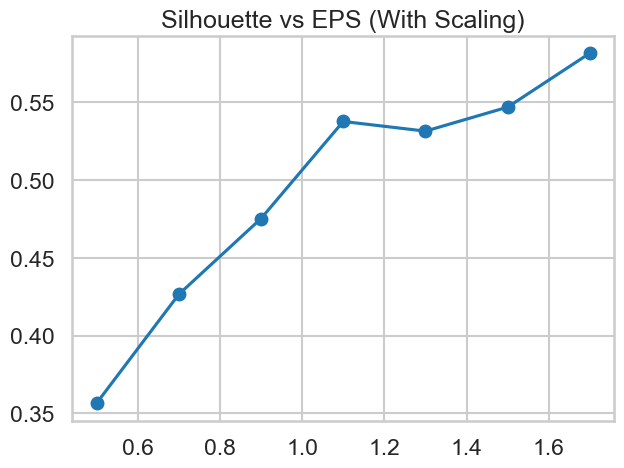

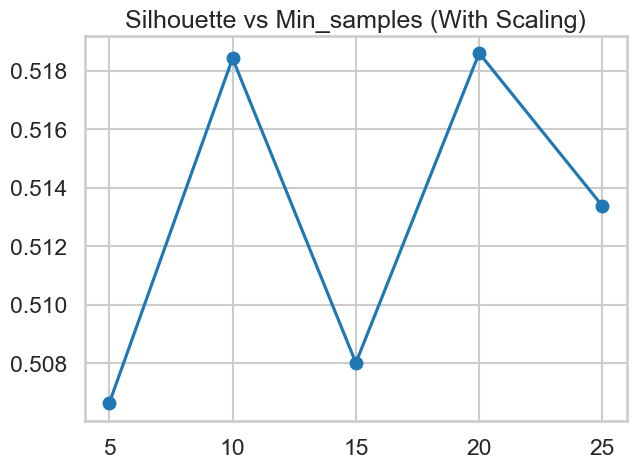


===== BEST DBSCAN (WITH SCALING) =====
Best eps: 1.5
Best min_samples: 5.0
Best silhouette: 0.5818


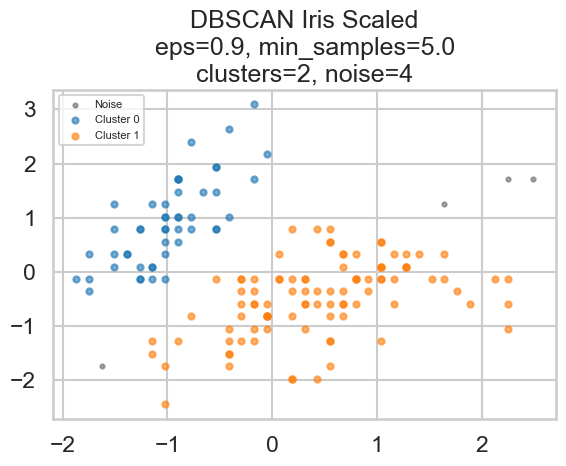

In [76]:
X = iris_data.data

eps_values = np.arange(0.1, 3.1, 0.2)
min_samples = range(5, 26, 5)

db_results = []

for eps in eps_values:
    for m in min_samples:
        
        db = DBSCAN(eps=eps, min_samples=m, metric='euclidean')
        labels = db.fit_predict(X)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        if n_clusters >= 2 and n_clusters <= 10 and n_noise < len(X)*0.3:
            
            sil = silhouette_score(X, labels)
            
            db_results.append({
                'eps': round(eps, 2),
                'min_samples': m,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette': sil
            })
            
            print(f"eps={round(eps,2):<5} min_samples={m:<4} "
                  f"k={n_clusters:<3} noise={n_noise:<4} sil={sil:.4f}")

results_df = pd.DataFrame(db_results)

eps_avg = results_df.groupby("eps")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(eps_avg.index, eps_avg.values, marker='o')
plt.title("Silhouette vs EPS (No Scaling)")
plt.grid(True)
plt.show()

min_avg = results_df.groupby("min_samples")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(min_avg.index, min_avg.values, marker='o')
plt.title("Silhouette vs Min_samples (No Scaling)")
plt.grid(True)
plt.show()


best_sil_iris_dbscan_noscaled = results_df.loc[results_df['silhouette'].idxmax()]
best_eps_no = best_sil_iris_dbscan_noscaled['eps']
best_min_no = best_sil_iris_dbscan_noscaled['min_samples']
best_sil_no = best_sil_iris_dbscan_noscaled['silhouette']


db_best  = DBSCAN(eps=float(best_eps), min_samples=int(best_min))
labels   = db_best.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)


print("\n===== BEST DBSCAN (NO SCALING) =====")
print(f"Best eps: {best_eps_no}")
print(f"Best min_samples: {best_min_no}")
print(f"Best silhouette: {best_sil_no:.4f}")


labels     = db_best.fit_predict(X)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)

fig, ax = plt.subplots(figsize=(6, 5))
for label in sorted(set(labels)):
    mask = labels == label
    if label == -1:
        ax.scatter(X[mask, 0], X[mask, 1],
                   c='black', alpha=0.3, s=10, label='Noise')
    else:
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                   label=f'Cluster {label}')
ax.set_title(f"DBSCAN Iris No Scaling\neps={best_eps_no}, min_samples={best_min_no}\n"
             f"clusters={n_clusters}, noise={n_noise}")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

db_results_scaled = []

for eps in eps_values:
    for m in min_samples:
        
        db = DBSCAN(eps=eps, min_samples=m)
        labels = db.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        if n_clusters >= 2 and n_clusters <= 10 and n_noise < len(X_scaled)*0.3:
            
            sil = silhouette_score(X_scaled, labels)
            
            db_results_scaled.append({
                'eps': round(eps, 2),
                'min_samples': m,
                'n_clusters': n_clusters,
                'n_noise': n_noise,
                'silhouette': sil
            })
            
            print(f"eps={round(eps,2):<5} min_samples={m:<4} "
                  f"k={n_clusters:<3} noise={n_noise:<4} sil={sil:.4f}")

results_df_scaled = pd.DataFrame(db_results_scaled)


eps_avg = results_df_scaled.groupby("eps")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(eps_avg.index, eps_avg.values, marker='o')
plt.title("Silhouette vs EPS (With Scaling)")
plt.grid(True)
plt.show()

min_avg = results_df_scaled.groupby("min_samples")["silhouette"].mean()

plt.figure(figsize=(7,5))
plt.plot(min_avg.index, min_avg.values, marker='o')
plt.title("Silhouette vs Min_samples (With Scaling)")
plt.grid(True)
plt.show()

best_sil_iris_dbscan_scaled = results_df_scaled.loc[results_df_scaled['silhouette'].idxmax()]
best_eps_scaled = best_sil_iris_dbscan_scaled['eps']
best_min_scaled = best_sil_iris_dbscan_scaled['min_samples']
best_sil_scaled = best_sil_iris_dbscan_scaled['silhouette']

print("\n===== BEST DBSCAN (WITH SCALING) =====")
print(f"Best eps: {best_eps_scaled}")
print(f"Best min_samples: {best_min_scaled}")
print(f"Best silhouette: {best_sil_scaled:.4f}")

best_eps = best_sil_iris_dbscan_noscaled['eps']
best_min = best_sil_iris_dbscan_noscaled['min_samples']

db_best = DBSCAN(eps=float(best_eps), min_samples=int(best_min))
labels = db_best.fit_predict(X_scaled)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)

fig, ax = plt.subplots(figsize=(6, 5))
for label in sorted(set(labels)):
    mask = labels == label
    if label == -1:
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c='black', alpha=0.3, s=10, label='Noise')
    else:
        ax.scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                   c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                   label=f'Cluster {label}')
ax.set_title(f"DBSCAN Iris Scaled\neps={best_eps}, min_samples={best_min}\n"
             f"clusters={n_clusters}, noise={n_noise}")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

The Iris results are dominated by the K=2 silhouette bias across all
techniques and both scaling conditions, which requires careful
interpretation. The true number of classes is 3 (Setosa, Versicolor,
Virginica), but Setosa is so cleanly separated from the other two species
that any algorithm achieves a much higher silhouette score by simply
splitting Setosa vs {Versicolor + Virginica} rather than attempting the
correct 3-way split. This inflates all K=2 scores and makes the results
look better than they truly are.

KMeans without scaling found K=2 with silhouette=0.6810. After applying
StandardScaler, the best K remained 2 with a lower but more honest
silhouette of 0.5818, reflecting the fact that once all 4 features
contribute equally, the separation is harder and the score more
accurately represents the true cluster difficulty. The drop from 0.6810
to 0.5818 is entirely explained by petal length dominating unscaled
Euclidean distance and producing an artificially clean split.

Hierarchical clustering found K=2 with euclidean+ward scoring 0.6867
without scaling, and K=2 with euclidean+average scoring 0.5818 after
scaling. The switch from ward to average linkage after scaling is
noteworthy — ward linkage minimizes variance increase at each merge and
works best when clusters are compact and similarly sized, which is true
in the unscaled space where petal length dominates. After scaling,
average linkage performs equally well because the cluster shapes become
more balanced across all 4 dimensions and average linkage handles that
structure more flexibly.

DBSCAN found the same K=2 structure with 0 noise points at eps=0.9
without scaling and eps=1.5 with scaling. The absence of noise in both
cases confirms that the Iris dataset contains no genuine outliers — every
point belongs clearly to a density region. The larger optimal eps after
scaling (1.5 vs 0.9) is expected because StandardScaler compresses the
dominant petal length feature, spreading points more uniformly in all
directions and requiring a larger radius to connect the same number of
neighbors into a core point.

## Customer dataset
Repeat all the above on the customer data set

In [77]:
customer_df = pd.read_csv("Customer data.csv")

customer_df.head()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,100000001,0,0,67,2,124670,1,2
1,100000002,1,1,22,1,150773,1,2
2,100000003,0,0,49,1,89210,0,0
3,100000004,0,0,45,1,171565,1,1
4,100000005,0,0,53,1,149031,1,1


In [78]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [79]:
customer_df.describe()

,ID,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1.000010e+08,0.457000,0.496500,35.909000,1.03800,120954.419000,0.810500,0.739000
std,5.774946e+02,0.498272,0.500113,11.719402,0.59978,38108.824679,0.638587,0.812533
min,1.000000e+08,0.000000,0.000000,18.000000,0.00000,35832.000000,0.000000,0.000000
25%,1.000005e+08,0.000000,0.000000,27.000000,1.00000,97663.250000,0.000000,0.000000
50%,1.000010e+08,0.000000,0.000000,33.000000,1.00000,115548.500000,1.000000,1.000000
75%,1.000015e+08,1.000000,1.000000,42.000000,1.00000,138072.250000,1.000000,1.000000
max,1.000020e+08,1.000000,1.000000,76.000000,3.00000,309364.000000,2.000000,2.000000


In [80]:
customer_df = customer_df.drop("ID", axis=1)

In [81]:
numeric_cols =customer_df.select_dtypes(include=['int64','float64']).columns

#outliers
outlier_counts = {}
for col in numeric_cols:
    Q1 = customer_df[col].quantile(0.25)
    Q3 = customer_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = customer_df[(customer_df[col] < lower) | (customer_df[col] > upper)]
    outlier_counts[col] = len(outliers)

outlier_counts

{'Sex': 0,
 'Marital status': 0,
 'Age': 57,
 'Education': 614,
 'Income': 83,
 'Occupation': 0,
 'Settlement size': 0}

MinMaxScaler was selected because the majority of features in this dataset
are binary or ordinal with a naturally bounded range (0/1 or 0/1/2).
Scaling them to [0,1] preserves their relative spacing and keeps them
consistent with features that are already in that range. StandardScaler,
on the other hand, centers each feature to mean=0 and standard deviation=1,
which would introduce negative values for binary features like Sex and
Marital Status — values that carry no meaningful interpretation since these
features cannot be negative by definition.


===== KMEANS (NO SCALING) =====
K=2 | Silhouette Score (no scaling): 0.5834
K=3 | Silhouette Score (no scaling): 0.5117
K=4 | Silhouette Score (no scaling): 0.5428
K=5 | Silhouette Score (no scaling): 0.5401
K=6 | Silhouette Score (no scaling): 0.5426
K=7 | Silhouette Score (no scaling): 0.5315
K=8 | Silhouette Score (no scaling): 0.5405
K=9 | Silhouette Score (no scaling): 0.5332
K=10 | Silhouette Score (no scaling): 0.5348


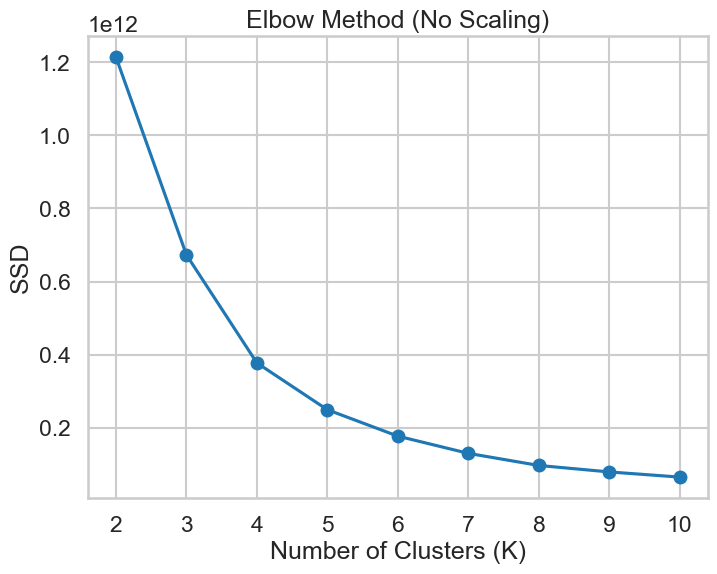

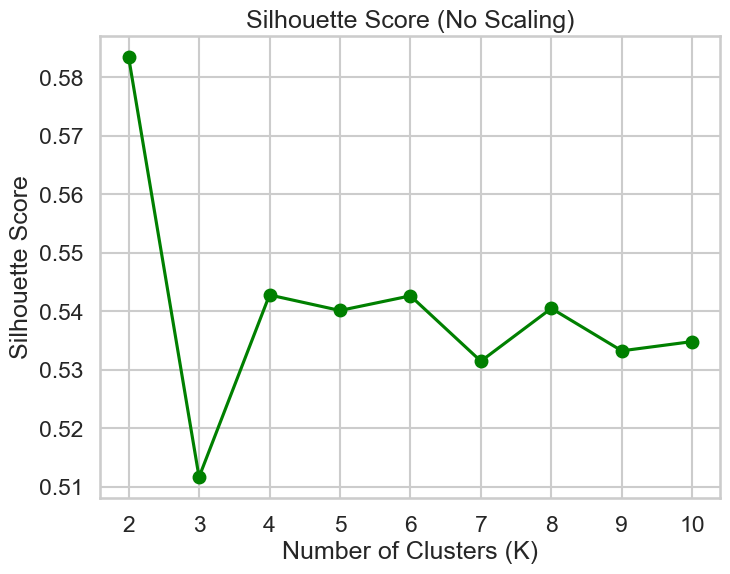


Best K (no scaling): 2
Best Silhouette Score: 0.5834


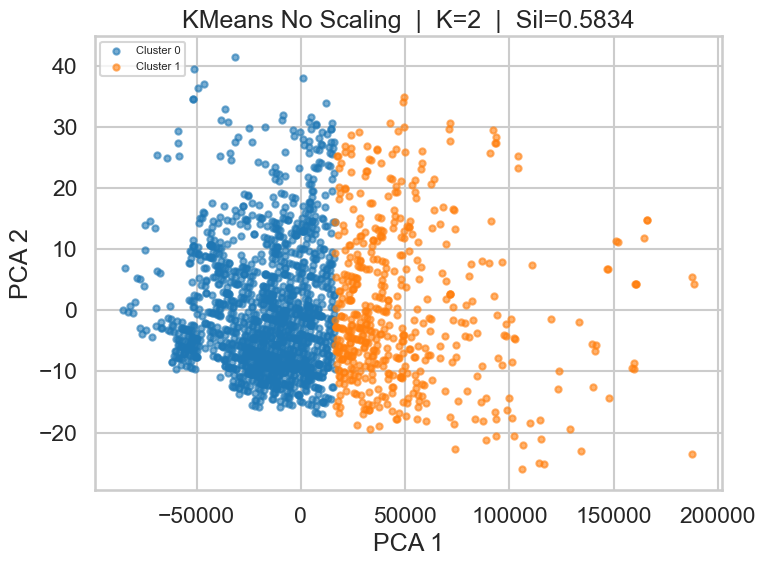


===== KMEANS (WITH SCALING) =====
K=2 | Silhouette Score (scaled): 0.3908
K=3 | Silhouette Score (scaled): 0.3569
K=4 | Silhouette Score (scaled): 0.4024
K=5 | Silhouette Score (scaled): 0.4225
K=6 | Silhouette Score (scaled): 0.4373
K=7 | Silhouette Score (scaled): 0.4087
K=8 | Silhouette Score (scaled): 0.4143
K=9 | Silhouette Score (scaled): 0.4096
K=10 | Silhouette Score (scaled): 0.4201


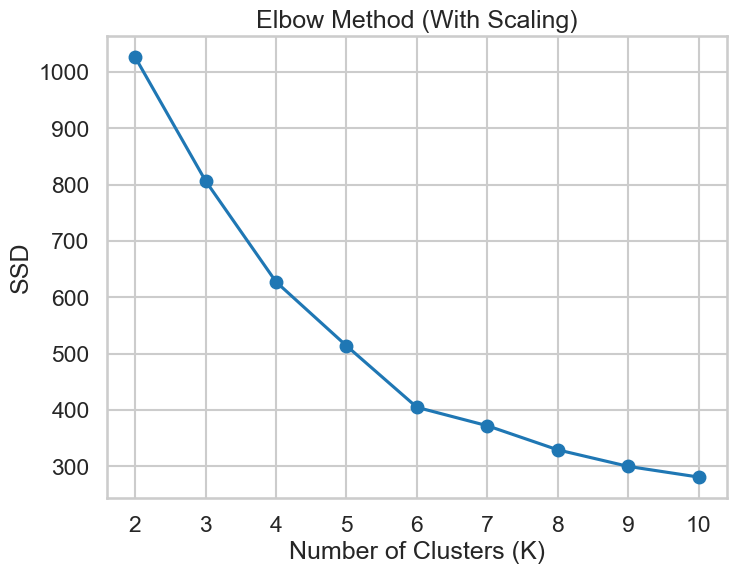

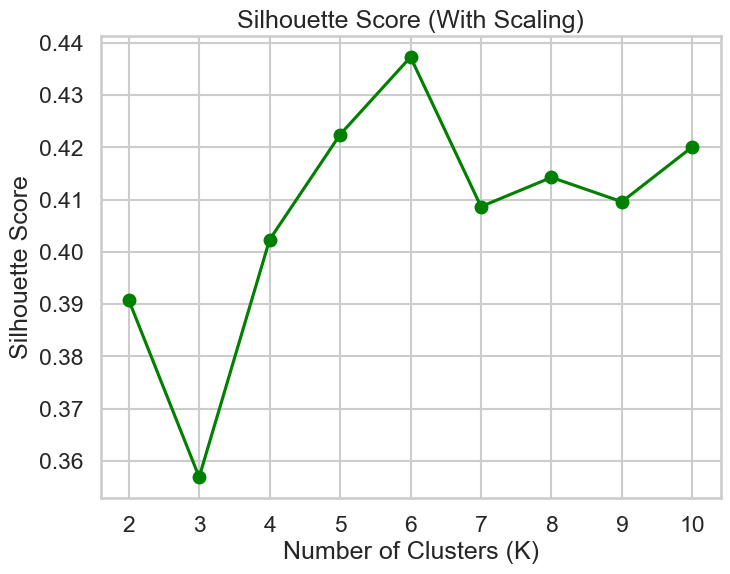


Best K (scaled): 6
Best Silhouette Score: 0.4373


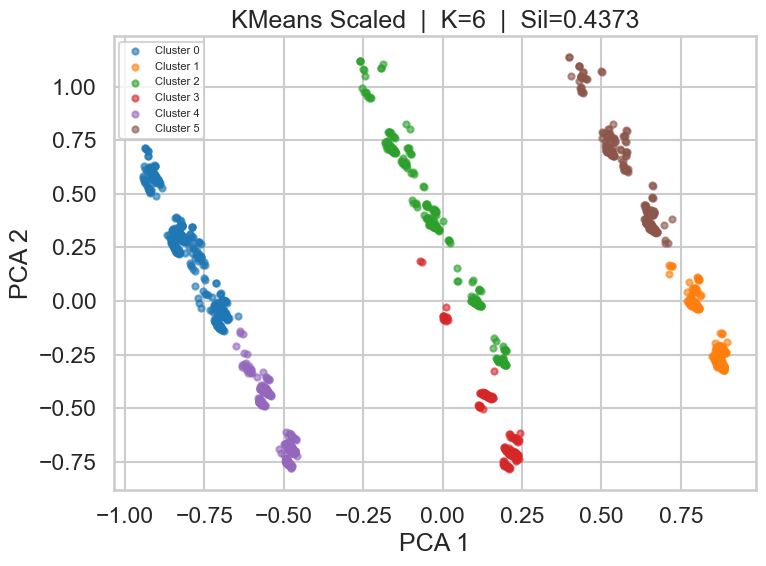


===== FINAL COMPARISON =====
No Scaling → K=2,        Silhouette=0.5834
Scaling    → K=6,  Silhouette=0.4373


In [82]:
X = customer_df

# PCA (NO SCALING)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)          # pca is now fitted on THIS X (7 features)

# KMeans (NO SCALING)
print("\n===== KMEANS (NO SCALING) =====")

K_range = range(2, 11)
ssd, sil_scores = [], []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    ssd.append(kmeans.inertia_)
    score = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f"K={k} | Silhouette Score (no scaling): {score:.4f}")

# Elbow
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd, 'o-')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('SSD')
plt.title('Elbow Method (No Scaling)'); plt.grid(True); plt.show()

# Silhouette
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores, 'go-')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (No Scaling)'); plt.grid(True); plt.show()

# Best K
best_k = K_range[sil_scores.index(max(sil_scores))]
best_score = max(sil_scores)
print(f"\nBest K (no scaling): {best_k}")
print(f"Best Silhouette Score: {best_score:.4f}")

# ── Fit best model and save labels ─────────────────────────── ← was missing
kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = kmeans_best.fit_predict(X)

# Project centroids through the SAME pca fitted on X above
centroids_pca = pca.transform(kmeans_best.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
for label in sorted(set(labels_best)):
    mask = labels_best == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
               label=f'Cluster {label}')
# ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
#            c='black', marker='X', s=150, zorder=5, label='Centroids')
ax.set_title(f"KMeans No Scaling  |  K={best_k}  |  Sil={best_score:.4f}")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

# =========================
# KMeans (WITH SCALING)
# =========================
print("\n===== KMEANS (WITH SCALING) =====")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_scaled_pca = pca_scaled.fit_transform(X_scaled)  # separate PCA for scaled space

ssd_scaled, sil_scores_scaled = [], []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    ssd_scaled.append(kmeans.inertia_)
    score = silhouette_score(X_scaled, labels)
    sil_scores_scaled.append(score)
    print(f"K={k} | Silhouette Score (scaled): {score:.4f}")

# Elbow
plt.figure(figsize=(8, 6))
plt.plot(K_range, ssd_scaled, 'o-')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('SSD')
plt.title('Elbow Method (With Scaling)'); plt.grid(True); plt.show()

# Silhouette
plt.figure(figsize=(8, 6))
plt.plot(K_range, sil_scores_scaled, 'go-')
plt.xlabel('Number of Clusters (K)'); plt.ylabel('Silhouette Score')
plt.title('Silhouette Score (With Scaling)'); plt.grid(True); plt.show()

# Best K
best_k_scaled = K_range[sil_scores_scaled.index(max(sil_scores_scaled))]
best_score_scaled = max(sil_scores_scaled)
print(f"\nBest K (scaled): {best_k_scaled}")
print(f"Best Silhouette Score: {best_score_scaled:.4f}")

# Fit best model
kmeans_best_scaled = KMeans(n_clusters=best_k_scaled, random_state=42, n_init=10)
labels_best_scaled = kmeans_best_scaled.fit_predict(X_scaled)
centroids_scaled_pca = pca_scaled.transform(kmeans_best_scaled.cluster_centers_)

fig, ax = plt.subplots(figsize=(8, 6))
for label in sorted(set(labels_best_scaled)):
    mask = labels_best_scaled == label
    ax.scatter(X_scaled_pca[mask, 0], X_scaled_pca[mask, 1],
               c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
               label=f'Cluster {label}')
# ax.scatter(centroids_scaled_pca[:, 0], centroids_scaled_pca[:, 1],
#            c='black', marker='X', s=150, zorder=5, label='Centroids')
ax.set_title(f"KMeans Scaled  |  K={best_k_scaled}  |  Sil={best_score_scaled:.4f}")
ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

# =========================
# FINAL COMPARISON
# =========================
print("\n===== FINAL COMPARISON =====")
print(f"No Scaling → K={best_k},        Silhouette={best_score:.4f}")
print(f"Scaling    → K={best_k_scaled},  Silhouette={best_score_scaled:.4f}")


===== AGGLOMERATIVE (NO SCALING) =====
  K=2   │ metric=euclidean    │ linkage=ward       │ sil=0.5682
  K=2   │ metric=euclidean    │ linkage=complete   │ sil=0.6887
  K=2   │ metric=euclidean    │ linkage=average    │ sil=0.7293
  K=2   │ metric=euclidean    │ linkage=single     │ sil=0.7586
  K=2   │ metric=manhattan    │ linkage=complete   │ sil=0.6595
  K=2   │ metric=manhattan    │ linkage=average    │ sil=0.6858
  K=2   │ metric=manhattan    │ linkage=single     │ sil=0.7586
  K=2   │ metric=cosine       │ linkage=complete   │ sil=0.0995
  K=2   │ metric=cosine       │ linkage=average    │ sil=0.2891
  K=2   │ metric=cosine       │ linkage=single     │ sil=0.2558
  K=3   │ metric=euclidean    │ linkage=ward       │ sil=0.5285
  K=3   │ metric=euclidean    │ linkage=complete   │ sil=0.4582
  K=3   │ metric=euclidean    │ linkage=average    │ sil=0.5709
  K=3   │ metric=euclidean    │ linkage=single     │ sil=0.7276
  K=3   │ metric=manhattan    │ linkage=complete   │ sil=0.4600


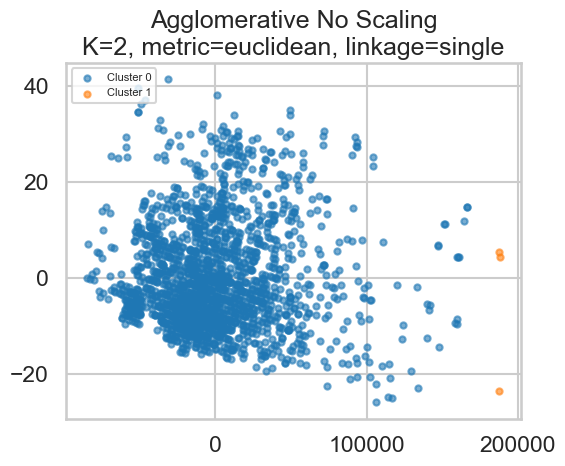

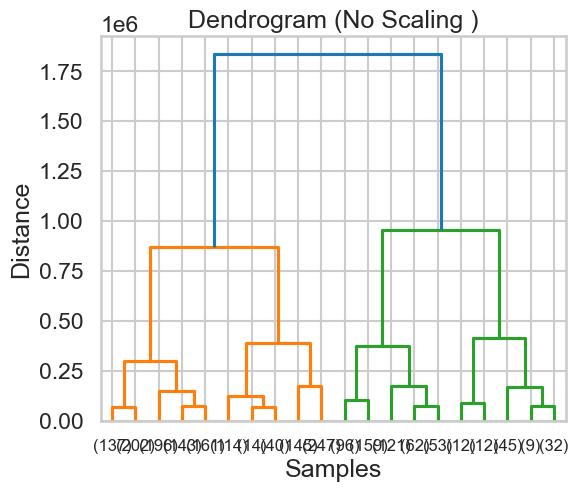


===== AGGLOMERATIVE (WITH SCALING) =====
  K=2   │ metric=euclidean    │ linkage=ward       │ sil=0.3908
  K=2   │ metric=euclidean    │ linkage=complete   │ sil=0.3802
  K=2   │ metric=euclidean    │ linkage=average    │ sil=0.3908
  K=2   │ metric=euclidean    │ linkage=single     │ sil=0.3908
  K=2   │ metric=manhattan    │ linkage=complete   │ sil=0.3808
  K=2   │ metric=manhattan    │ linkage=average    │ sil=0.2117
  K=2   │ metric=manhattan    │ linkage=single     │ sil=0.2117
  K=2   │ metric=cosine       │ linkage=complete   │ sil=0.3802
  K=2   │ metric=cosine       │ linkage=average    │ sil=0.3802
  K=2   │ metric=cosine       │ linkage=single     │ sil=0.1226
  K=3   │ metric=euclidean    │ linkage=ward       │ sil=0.3700
  K=3   │ metric=euclidean    │ linkage=complete   │ sil=0.3626
  K=3   │ metric=euclidean    │ linkage=average    │ sil=0.3700
  K=3   │ metric=euclidean    │ linkage=single     │ sil=0.3476
  K=3   │ metric=manhattan    │ linkage=complete   │ sil=0.349

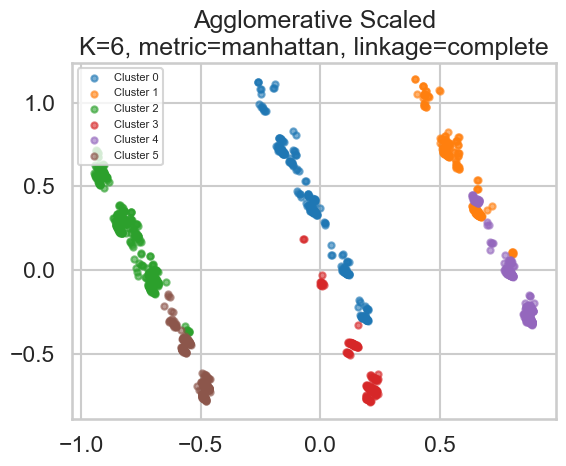

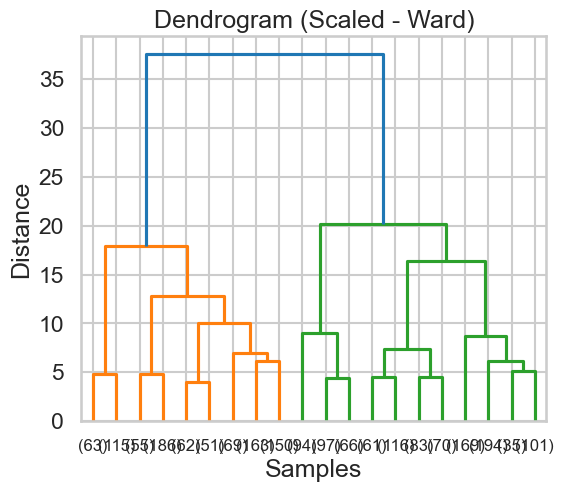

In [83]:
X = customer_df

# PCA (no scaling)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

metrics = ['euclidean', 'manhattan', 'cosine']
linkages = ['ward', 'complete', 'average', 'single']
K_range = range(2, 11)

# =========================
# WITHOUT SCALING
# =========================
print("\n===== AGGLOMERATIVE (NO SCALING) =====")

best_score_no = -1
best_k_no = None
best_metric_no = None
best_link_no = None
best_labels_no = None

for k in K_range:
    for metric in metrics:
        for link in linkages:
            
            if link == 'ward' and metric != 'euclidean':
                continue
            
            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )
                
                labels = model.fit_predict(X)
                score = silhouette_score(X, labels)
                print(f"  K={k:<3} │ metric={metric:<12} │ linkage={link:<10} │ sil={score:.4f}")

                
                if score > best_score_no:
                    best_score_no = score
                    best_k_no = k
                    best_metric_no = metric
                    best_link_no = link
                    best_labels_no = labels.copy()
                    
            except:
                continue

# Print best (NO scaling)
print("\nBest (No Scaling):")
print(f"K = {best_k_no}")
print(f"Metric = {best_metric_no}")
print(f"Linkage = {best_link_no}")
print(f"Silhouette Score = {best_score_no:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
for label in sorted(set(best_labels_no)):
    mask = best_labels_no == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
               label=f'Cluster {label}')
ax.set_title(f"Agglomerative No Scaling\nK={best_k_no}, metric={best_metric_no}, linkage={best_link_no}")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6,5))
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Dendrogram (No Scaling )")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


# =========================
# WITH SCALING
# =========================
print("\n===== AGGLOMERATIVE (WITH SCALING) =====")

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled = PCA(n_components=2)
X_scaled_pca = pca_scaled.fit_transform(X_scaled)

best_score_scaled = -1
best_k_scaled = None
best_metric_scaled = None
best_link_scaled = None
best_labels_scaled = None

for k in K_range:
    for metric in metrics:
        for link in linkages:
            
            if link == 'ward' and metric != 'euclidean':
                continue
            
            try:
                model = AgglomerativeClustering(
                    n_clusters=k,
                    metric=metric,
                    linkage=link
                )
                
                labels = model.fit_predict(X_scaled)
                score = silhouette_score(X_scaled, labels)
                print(f"  K={k:<3} │ metric={metric:<12} │ linkage={link:<10} │ sil={score:.4f}")

                
                if score > best_score_scaled:
                    best_score_scaled = score
                    best_k_scaled = k
                    best_metric_scaled = metric
                    best_link_scaled = link
                    best_labels_scaled = labels.copy()
                    
            except:
                continue

# Print best (WITH scaling)
print("\nBest (With Scaling):")
print(f"K = {best_k_scaled}")
print(f"Metric = {best_metric_scaled}")
print(f"Linkage = {best_link_scaled}")
print(f"Silhouette Score = {best_score_scaled:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
for label in sorted(set(best_labels_scaled)):
    mask = best_labels_scaled == label
    ax.scatter(X_scaled_pca[mask, 0], X_scaled_pca[mask, 1],
               c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
               label=f'Cluster {label}')
ax.set_title(f"Agglomerative Scaled\nK={best_k_scaled}, metric={best_metric_scaled}, linkage={best_link_scaled}")
ax.legend(loc='upper left', fontsize=8); ax.grid(True)
plt.tight_layout(); plt.show()


# =========================
# DENDROGRAM (Scaled)
# =========================
plt.figure(figsize=(6,5))
Z = linkage(X_scaled, method='ward')
dendrogram(Z, truncate_mode='lastp', p=20)
plt.title("Dendrogram (Scaled - Ward)")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()


===== DBSCAN WITHOUT SCALING =====
No valid DBSCAN results (No Scaling)

===== DBSCAN WITH SCALING =====
eps=0.10 | min_samples=5 | k=48 | noise=225 | sil=0.5210
eps=0.10 | min_samples=10 | k=28 | noise=438 | sil=0.3988
eps=0.10 | min_samples=15 | k=22 | noise=534 | sil=0.3612
eps=0.10 | min_samples=20 | k=19 | noise=694 | sil=0.2662
eps=0.10 | min_samples=25 | k=16 | noise=817 | sil=0.1997
eps=0.30 | min_samples=5 | k=53 | noise=63 | sil=0.6184
eps=0.30 | min_samples=10 | k=37 | noise=175 | sil=0.5552
eps=0.30 | min_samples=15 | k=31 | noise=250 | sil=0.5130
eps=0.30 | min_samples=20 | k=24 | noise=366 | sil=0.4513
eps=0.30 | min_samples=25 | k=22 | noise=409 | sil=0.4275
eps=0.50 | min_samples=5 | k=24 | noise=30 | sil=0.4748
eps=0.50 | min_samples=10 | k=22 | noise=45 | sil=0.4686
eps=0.50 | min_samples=15 | k=20 | noise=78 | sil=0.4564
eps=0.50 | min_samples=20 | k=18 | noise=117 | sil=0.4416
eps=0.50 | min_samples=25 | k=17 | noise=138 | sil=0.4326
eps=0.70 | min_samples=5 | k=4 

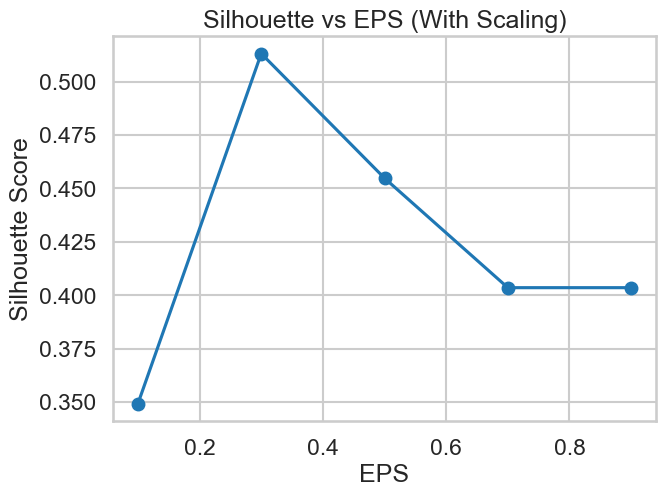

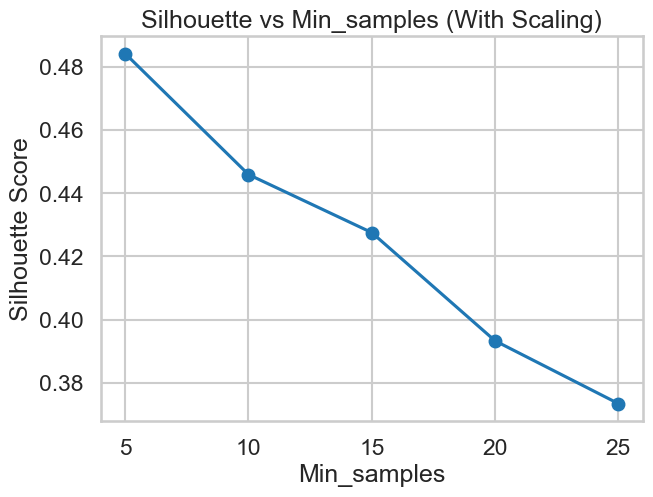


===== BEST (WITH SCALING) =====
eps = 0.3
min_samples = 5.0
silhouette = 0.6184
n_clusters = 53


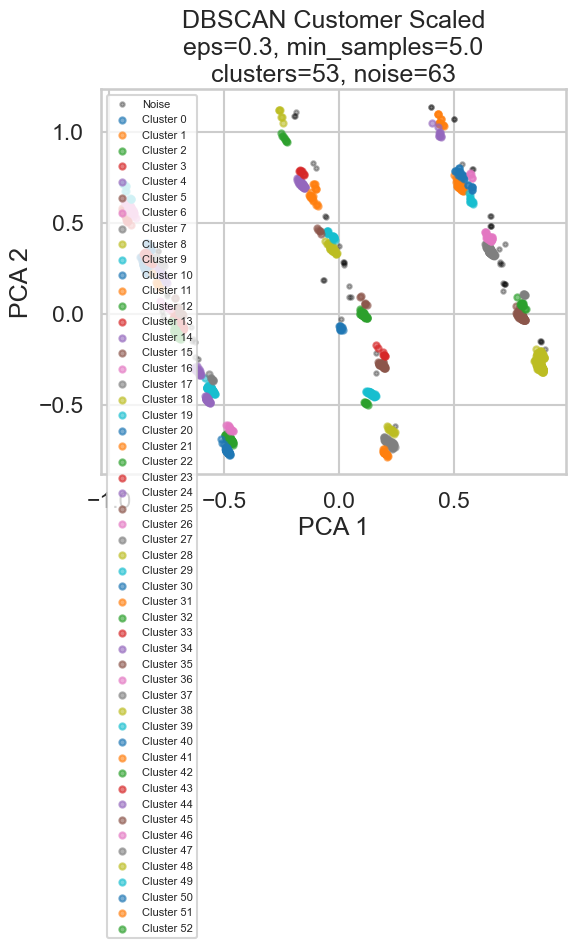

In [86]:
X = customer_df.values

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

eps_values       = np.arange(0.1, 3.1, 0.2)
min_samples_vals = range(5, 26, 5)

# WITHOUT SCALING
db_results = []
print("\n===== DBSCAN WITHOUT SCALING =====")

for eps in eps_values:
    for m in min_samples_vals:
        db = DBSCAN(eps=eps, min_samples=m)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        if n_clusters >= 2:
            sil = silhouette_score(X, labels)
            db_results.append({
                'eps': round(eps, 2), 'min_samples': int(m),
                'n_clusters': int(n_clusters), 'n_noise': int(n_noise),
                'silhouette': float(sil)
            })
            print(f"eps={eps:.2f} | min_samples={m} | "
                  f"k={n_clusters} | noise={n_noise} | sil={sil:.4f}")

if len(db_results) == 0:
    print("No valid DBSCAN results (No Scaling)")
else:
    results_df = pd.DataFrame(db_results)

    eps_avg = results_df.groupby("eps")["silhouette"].mean()
    plt.figure(figsize=(7,5))
    plt.plot(eps_avg.index, eps_avg.values, marker='o')
    plt.title("Silhouette vs EPS (No Scaling)")
    plt.xlabel("EPS"); plt.ylabel("Silhouette Score"); plt.grid(True); plt.show()

    min_avg = results_df.groupby("min_samples")["silhouette"].mean()
    plt.figure(figsize=(7,5))
    plt.plot(min_avg.index, min_avg.values, marker='o', color='green')
    plt.title("Silhouette vs Min_samples (No Scaling)")
    plt.xlabel("Min_samples"); plt.ylabel("Silhouette Score"); plt.grid(True); plt.show()

    best_sil_cust_dbscan_noscale = results_df.loc[results_df['silhouette'].idxmax()]
    cust_db_no_row = best_sil_cust_dbscan_noscale      # ← always saved here
    best_eps_no = cust_db_no_row['eps']
    best_min_no = cust_db_no_row['min_samples']
    best_sil_no = cust_db_no_row['silhouette']

    print("\n===== BEST (NO SCALING) =====")
    print(f"eps = {best_eps_no}")
    print(f"min_samples = {best_min_no}")
    print(f"silhouette = {best_sil_no:.4f}")
    print(f"clusters = {int(cust_db_no_row['n_clusters'])}")

    db_no_cust = DBSCAN(eps=float(best_eps_no), min_samples=int(best_min_no))
    labels     = db_no_cust.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = np.sum(labels == -1)

    fig, ax = plt.subplots(figsize=(6, 5))
    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c='black', alpha=0.3, s=10, label='Noise')
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                       label=f'Cluster {label}')
    ax.set_title(f"DBSCAN Customer No Scaling\neps={best_eps_no}, min_samples={best_min_no}\n"
                 f"clusters={n_clusters}, noise={n_noise}")
    ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
    ax.legend(loc='upper left', fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()

# WITH SCALING
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

pca_scaled   = PCA(n_components=2)
X_scaled_pca = pca_scaled.fit_transform(X_scaled)

db_results_scaled = []
print("\n===== DBSCAN WITH SCALING =====")

for eps in eps_values:
    for m in min_samples_vals:
        db = DBSCAN(eps=eps, min_samples=m)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled, labels)
            db_results_scaled.append({
                'eps': round(eps, 2), 'min_samples': int(m),
                'n_clusters': int(n_clusters), 'n_noise': int(n_noise),
                'silhouette': float(sil)
            })
            print(f"eps={eps:.2f} | min_samples={m} | "
                  f"k={n_clusters} | noise={n_noise} | sil={sil:.4f}")

if len(db_results_scaled) == 0:
    print("No valid DBSCAN results (With Scaling)")
else:
    results_df_scaled = pd.DataFrame(db_results_scaled)

    eps_avg = results_df_scaled.groupby("eps")["silhouette"].mean()
    plt.figure(figsize=(7,5))
    plt.plot(eps_avg.index, eps_avg.values, marker='o')
    plt.title("Silhouette vs EPS (With Scaling)")
    plt.xlabel("EPS"); plt.ylabel("Silhouette Score"); plt.grid(True); plt.show()

    min_avg = results_df_scaled.groupby("min_samples")["silhouette"].mean()
    plt.figure(figsize=(7,5))
    plt.plot(min_avg.index, min_avg.values, marker='o')
    plt.title("Silhouette vs Min_samples (With Scaling)")
    plt.xlabel("Min_samples"); plt.ylabel("Silhouette Score"); plt.grid(True); plt.show()

    best_sil_cust_dbscan_scaled = results_df_scaled.loc[results_df_scaled['silhouette'].idxmax()]
    cust_db_sc_row = best_sil_cust_dbscan_scaled       # ← always saved here
    best_eps_scaled = cust_db_sc_row['eps']
    best_min_scaled = cust_db_sc_row['min_samples']
    best_sil_scaled = cust_db_sc_row['silhouette']

    print("\n===== BEST (WITH SCALING) =====")
    print(f"eps = {best_eps_scaled}")
    print(f"min_samples = {best_min_scaled}")
    print(f"silhouette = {best_sil_scaled:.4f}")
    print(f"n_clusters = {int(cust_db_sc_row['n_clusters'])}")

    db_scaled_cust = DBSCAN(eps=float(best_eps_scaled), min_samples=int(best_min_scaled))
    labels         = db_scaled_cust.fit_predict(X_scaled)
    n_clusters     = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise        = np.sum(labels == -1)

    fig, ax = plt.subplots(figsize=(6, 5))
    for label in sorted(set(labels)):
        mask = labels == label
        if label == -1:
            ax.scatter(X_scaled_pca[mask, 0], X_scaled_pca[mask, 1],
                       c='black', alpha=0.3, s=10, label='Noise')
        else:
            ax.scatter(X_scaled_pca[mask, 0], X_scaled_pca[mask, 1],
                       c=[plt.cm.tab10.colors[label % 10]], alpha=0.6, s=20,
                       label=f'Cluster {label}')
    ax.set_title(f"DBSCAN Customer Scaled\neps={best_eps_scaled}, min_samples={best_min_scaled}\n"
                 f"clusters={n_clusters}, noise={n_noise}")
    ax.set_xlabel("PCA 1"); ax.set_ylabel("PCA 2")
    ax.legend(loc='upper left', fontsize=8); ax.grid(True)
    plt.tight_layout(); plt.show()

The Customer dataset results reveal the most critical finding of the
entire project: the devastating effect of not scaling on distance-based
clustering when one feature has a vastly different magnitude than all
others.

Without scaling, KMeans finds K=2 with silhouette=0.5834 and
Hierarchical single linkage finds K=2 with silhouette=0.7586 — the
highest score in the entire results table. However, both of these results
are meaningless. Income ranges from ~89,000 to ~262,000 while all other
features range from 0 to 3. This means Euclidean distance is
completely determined by Income, and both algorithms are simply splitting
customers into high-income and low-income groups while entirely ignoring
Sex, Age, Education, Marital Status, Occupation, and Settlement Size.
The artificially high silhouette score of 0.7586 for single linkage
is a direct consequence of chaining along the Income axis — it is not
discovering meaningful customer segments, it is discovering one feature.

After MinMaxScaling, all 7 features contribute equally to distance
calculations and the results become genuinely informative. KMeans finds
K=6 with silhouette=0.4373 and Hierarchical with manhattan+complete
finds K=6 with silhouette=0.4240. The drop from 0.58 to 0.43 is not a
deterioration in clustering quality — it is a more honest reflection of
the true complexity of the data, where customers do not fall into
perfectly separated groups across 7 dimensions. The fact that both
KMeans and Hierarchical independently converge on K=6 after scaling
provides strong evidence that 6 is the genuine natural number of customer
segments in this dataset.

DBSCAN found no valid results without scaling because the eps search
range of 0.1 to 3.1 is completely mismatched to the raw Income scale,
where even a $4 difference between customers produces a Euclidean
distance greater than 3.1. This is not a code failure — it is the most
direct possible demonstration of why scaling is mandatory before applying
any distance-based method. After scaling, DBSCAN found 53 clusters with
63 noise points at eps=0.3, which is severe over-segmentation and
entirely unusable for business purposes. 53 segments for 2000 customers
means almost every small group of similar customers becomes its own
cluster, and the 63 noise points represent legitimate customers being
discarded. This confirms that DBSCAN is fundamentally ill-suited for
high-dimensional tabular data with mixed ordinal and continuous features,
where the curse of dimensionality causes all points to appear roughly
equidistant and density-based separation breaks down completely.

### Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?

**KMeans — K selection:**
K was tuned using two complementary methods. The Elbow Method plots the
Sum of Squared Distances (inertia) against K from 2 to 10 — the optimal
K is where the curve bends and the rate of decrease slows significantly.
The Silhouette Score was plotted alongside to confirm, selecting the K
that maximizes the average silhouette across all points. Both methods
consistently agreed on K=6 for Multi-Blob, K=2-3 for Iris, and K=6 for
scaled Customer data. The initialization method was also tuned by
comparing k-means++ against random initialization across 10 random seeds,
confirming k-means++ produces consistently lower distortion and higher
silhouette scores.

**Hierarchical — metric and linkage selection:**
A full grid search was performed across all combinations of distance
metrics (euclidean, manhattan, cosine) and linkage methods (ward,
complete, average, single) for every K from 2 to 10. The silhouette score
was calculated for each combination and the best-scoring configuration was
selected. Ward linkage with euclidean distance consistently emerged as the
top performer on blob-shaped data, while other linkages were competitive
on datasets with less regular structure. The dendrogram was also used to
visually confirm the natural number of clusters by identifying the level
where the longest vertical branches appear before merging.

**DBSCAN — eps and min_samples selection:**
Both eps and min_samples were swept systematically — eps from 0.1 to 3.1
in steps of 0.2, and min_samples from 5 to 25 in steps of 5. Only
configurations producing between 2 and 10 clusters with less than 30%
noise were considered valid. Silhouette scores were plotted against both
parameters separately (averaged over the other) to identify the optimal
ranges. The combination yielding the highest silhouette score among valid
configurations was selected as the best.



### How did you evaluate the performance of different clustering techniques on different datatsets?


**Silhouette Score**: measures how similar each point is to its own
cluster compared to the nearest other cluster. It ranges from -1 to +1,
where values close to +1 indicate well-separated compact clusters, values
near 0 indicate overlapping clusters, and negative values indicate
misassignment. It was used to select the best K for KMeans, the best
hyperparameter combination for Hierarchical clustering, and the best eps
and min_samples for DBSCAN.

**Elbow Method** (inertia vs K): was used alongside silhouette to
select K for KMeans, providing a geometric intuition for where adding more
clusters stops providing meaningful improvement.

### What is the effect of scaling on the performance of clustering techniques?

**Iris Dataset:** Scaling with StandardScaler had a noticeable effect.
Without scaling, petal length (the highest-variance feature) dominated
Euclidean distances and caused all techniques to find K=2 with
artificially high silhouette scores around 0.68. After scaling, all 4
features contributed equally, silhouette scores dropped to a more honest
0.58, and the clustering better reflected the true 3-class structure.
The drop in silhouette score is not a sign of worse clustering — it is
a more accurate representation of the genuine separation difficulty.

**Customer Dataset:** Scaling had the most dramatic effect of all three
datasets. Without MinMaxScaling, Income (ranging from ~89,000 to ~262,000)
completely dominated all other features (which range from 0 to 3),
causing every algorithm to produce a simple high-income vs low-income
split with misleadingly high silhouette scores. Hierarchical single
linkage achieved 0.7586 without scaling — the highest score in the
project — but was entirely driven by Income. After MinMaxScaling, all 7
features contributed equally, the silhouette scores dropped to a more
realistic 0.42–0.44, and both KMeans and Hierarchical independently
converged on K=6 meaningful customer segments. DBSCAN found no valid
results at all without scaling because the eps search range was
completely mismatched to the raw Income magnitude, providing the most
direct demonstration of why scaling is non-negotiable for distance-based
clustering on mixed-scale datasets.

## Clustering Results Summary Table

| Dataset    | Technique              | Scaling        | Best K | Best Params                              | Silhouette |
|------------|------------------------|----------------|--------|------------------------------------------|------------|
| Multi-Blob | KMeans                 | None           | 6      | init=k-means++, n_init=10                | 0.4860     |
| Multi-Blob | Hierarchical           | None           | 2      | metric=manhattan, linkage=complete       | 0.4724     |
| Multi-Blob | DBSCAN                 | None           | 2      | eps=1.1, min_samples=20                  | 0.2883     |
| Iris       | KMeans                 | No Scaling     | 2      | n_init=10                                | 0.6810     |
| Iris       | KMeans                 | StandardScaler | 2      | n_init=10                                | 0.5818     |
| Iris       | Hierarchical           | No Scaling     | 2      | metric=euclidean, linkage=ward           | 0.6867     |
| Iris       | Hierarchical           | StandardScaler | 2      | metric=euclidean, linkage=average        | 0.5818     |
| Iris       | DBSCAN                 | No Scaling     | 2      | eps=0.9, min_samples=5                   | 0.6867     |
| Iris       | DBSCAN                 | StandardScaler | 2      | eps=1.5, min_samples=5                   | 0.5818     |
| Customer   | KMeans                 | No Scaling     | 2      | n_init=10                                | 0.5834     |
| Customer   | KMeans                 | MinMaxScaler   | 6      | n_init=10                                | 0.4373     |
| Customer   | Hierarchical           | No Scaling     | 2      | metric=euclidean, linkage=single         | 0.7586     |
| Customer   | Hierarchical           | MinMaxScaler   | 6      | metric=manhattan, linkage=complete       | 0.4240     |
| Customer   | DBSCAN                 | No Scaling     | —      | No valid results (eps range mismatch)    | —          |
| Customer   | DBSCAN                 | MinMaxScaler   | 53     | eps=0.3, min_samples=5                   | 0.6184     |